In [1]:
# =============================================================================
# JEPCO Smart Meter — Forecasting Notebook (Walk-Forward Edition)
# =============================================================================
# Goal      : Predict total kWh for the NEXT calendar month (scalar output)
# Input     : Last 30 days (1,440 half-hourly slots) per sample
# Targets   : (A) per-meter monthly kWh  (B) area-level monthly kWh
# Split     : 6-fold walk-forward — loaded from pipeline splits/ folder
#             fold{N}_train.csv | fold{N}_val.csv | fold{N}_test.csv
# Windowing : Slide every 1 month (non-overlapping) → ~11 samples per meter
# Model     : Minimal 1-layer LSTM → Linear head  (one model trained per fold)
# Features  : Auto-detected from pipeline output columns
#             Includes: year_sin/cos, cumkwh_in_month, area_load_lag_48, etc.
#             Excluded: season (not in pipeline), is_eid (not in pipeline),
#                       is_imputed_linear/seasonal/knn (granular flags dropped)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings, gc, math, os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.7.0+cu128


In [2]:
# =============================================================================
# CONFIG
# =============================================================================

CFG = dict(
    # ── paths — pipeline saves splits here ───────────────────────────────────
    splits_dir   = 'splits',          # folder written by pipeline Section 15
    N_FOLDS      = 6,                 # must match pipeline FOLDS list

    # ── windowing ─────────────────────────────────────────────────────────────
    INPUT_STEPS      = 1440,   # 30 days × 48 half-hourly slots  (per-meter)
    AREA_INPUT_STEPS = 672,    # 14 days × 48 slots (area — more samples)

    # ── model ─────────────────────────────────────────────────────────────────
    HIDDEN_SIZE = 64,
    NUM_LAYERS  = 1,
    DROPOUT     = 0.2,

    # ── training ──────────────────────────────────────────────────────────────
    BATCH_SIZE  = 64,
    LR          = 1e-3,
    EPOCHS      = 40,
    PATIENCE    = 7,
    GRAD_CLIP   = 1.0,

    # ── calendar ──────────────────────────────────────────────────────────────
    RAMADAN_START = '2025-03-01',
    RAMADAN_END   = '2025-03-30',
)

# Columns produced by the pipeline (Section 10 feature engineering).
# These are the CANDIDATE feature columns — FEATS will be resolved at
# load time to only include columns that actually exist in the CSVs.
# Order: target first, then time encodings, flags, lags, rolling, billing, area.
FEATURE_COLS = [
    'A+KWH',                      # target — always first
    'slot_sin',  'slot_cos',       # time-of-day (30-min, 24h cycle)
    'dow_sin',   'dow_cos',        # day-of-week (7d cycle)
    'month_sin', 'month_cos',      # month seasonality (12m cycle)
    'year_sin',  'year_cos',       # annual seasonality (365d cycle)
    'is_weekend',                  # Fri–Sat flag
    'is_business_hour',            # 08:00–15:59 flag
    'is_ramadan',                  # Ramadan window flag
    'lag_1',   'lag_48',  'lag_336',           # 30min / 24h / 7d lags
    'roll_mean_48', 'roll_std_48', 'roll_mean_336',  # rolling stats
    'cumkwh_in_month',             # cumulative billing accumulation
    'billing_tier',                # tariff bracket (0/1/2)
    'area_load_lag_48',            # neighbourhood avg 24h ago
    'area_load_roll_mean_336',     # neighbourhood 7-day rolling avg
    'is_imputed',                  # single imputation flag
]

TARGET_COL = 'A+KWH'

print('Config ready.')
print(f'Candidate feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Config ready.
Candidate feature columns (23): ['A+KWH', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos', 'is_weekend', 'is_business_hour', 'is_ramadan', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'cumkwh_in_month', 'billing_tier', 'area_load_lag_48', 'area_load_roll_mean_336', 'is_imputed']


In [3]:
# =============================================================================
# SECTION 1 — Load 6-fold walk-forward splits from pipeline
# =============================================================================
# The pipeline (Section 13–15) saved:
#   splits/fold1_train.csv … splits/fold6_test.csv
#
# Each fold covers ALL meters; the train/val/test boundary is TIME-based:
#   Train: Dec 8 → fold train_end   (grows each fold)
#   Val  : 1 calendar month after train_end
#   Test : 1 calendar month after val_end
#
# We load all 6 folds into a list of dicts for fold-by-fold training.
# =============================================================================

print('=' * 60)
print('SECTION 1 — Load 6-Fold Walk-Forward Splits')
print('=' * 60)

# Columns produced by the pipeline that are NOT model features
_DROP_COLS = [
    'is_imputed_linear', 'is_imputed_seasonal', 'is_imputed_knn',  # granular flags
]

def load_fold(fold_num, splits_dir):
    """Load one fold's train/val/test CSVs. Returns dict of DataFrames."""
    out = {}
    for split in ('train', 'val', 'test'):
        path = os.path.join(splits_dir, f'fold{fold_num}_{split}.csv')
        df = pd.read_csv(path, parse_dates=['freeze_date'])
        df = df.sort_values(['meter_B', 'freeze_date']).reset_index(drop=True)
        df = df.drop(columns=[c for c in _DROP_COLS if c in df.columns])
        out[split] = df
    return out

folds_data = []   # list of {'fold': N, 'train': df, 'val': df, 'test': df}
for f in range(1, CFG['N_FOLDS'] + 1):
    fd = load_fold(f, CFG['splits_dir'])
    fd['fold'] = f
    folds_data.append(fd)

# Resolve FEATS from fold 1 train (all folds share the same schema)
sample_df = folds_data[0]['train']
FEATS   = [c for c in FEATURE_COLS if c in sample_df.columns]
missing = [c for c in FEATURE_COLS if c not in sample_df.columns]

if missing:
    print(f'  INFO — FEATURE_COLS entries not found in CSVs (skipped): {missing}')
print(f'  Features resolved ({len(FEATS)}): {FEATS}')
print()

# Summary table
print(f"  {'Fold':<6} {'Train rows':>11} {'Val rows':>9} {'Test rows':>10} "
      f"{'Train meters':>14} {'Train start':>12} {'Test end':>10}")
print(f"  {'─'*6} {'─'*11} {'─'*9} {'─'*10} {'─'*14} {'─'*12} {'─'*10}")
for fd in folds_data:
    tr, va, te = fd['train'], fd['val'], fd['test']
    print(f"  {fd['fold']:<6} {len(tr):>11,} {len(va):>9,} {len(te):>10,} "
          f"{tr['meter_B'].nunique():>14} "
          f"{str(tr['freeze_date'].min().date()):>12} "
          f"{str(te['freeze_date'].max().date()):>10}")

SECTION 1 — Load 6-Fold Walk-Forward Splits
  Features resolved (23): ['A+KWH', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos', 'is_weekend', 'is_business_hour', 'is_ramadan', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'cumkwh_in_month', 'billing_tier', 'area_load_lag_48', 'area_load_roll_mean_336', 'is_imputed']

  Fold    Train rows  Val rows  Test rows   Train meters  Train start   Test end
  ────── ─────────── ───────── ────────── ────────────── ──────────── ──────────
  1        5,518,656 1,196,352  1,157,760            804   2024-12-08 2025-06-30
  2        6,715,008 1,157,760  1,196,352            804   2024-12-08 2025-07-31
  3        7,872,768 1,196,352  1,196,352            804   2024-12-08 2025-08-31
  4        9,069,120 1,196,352  1,157,760            804   2024-12-08 2025-09-30
  5       10,265,472 1,157,760  1,196,352            804   2024-12-08 2025-10-31
  6       11,423,232 1,196,352  1,

In [4]:
# =============================================================================
# SECTION 2 — Area-level aggregation (per fold)
# =============================================================================
# For the walk-forward setup ALL meters are present in every fold's train/val/test
# (the split is by time, not by meter). We therefore aggregate across ALL meters
# at each timestamp to get the area-level time series for each split.
#
# Area A+KWH = sum of all meter readings at that timestamp.
# All other feature columns = mean across meters (they are per-slot, not per-meter).
# =============================================================================

print('=' * 60)
print('SECTION 2 — Area Aggregation (per fold)')
print('=' * 60)

def make_area(df, feats, target_col):
    """Collapse per-meter rows into one area-level time series."""
    agg_dict = {target_col: 'sum'}
    for c in feats:
        if c != target_col:
            agg_dict[c] = 'mean'
    return (df.groupby('freeze_date')
              .agg(agg_dict)
              .reset_index()
              .sort_values('freeze_date')
              .reset_index(drop=True))

for fd in folds_data:
    fd['area_train'] = make_area(fd['train'], FEATS, TARGET_COL)
    fd['area_val']   = make_area(fd['val'],   FEATS, TARGET_COL)
    fd['area_test']  = make_area(fd['test'],  FEATS, TARGET_COL)

print(f"  Fold 1 area rows — train: {len(folds_data[0]['area_train']):,}  "
      f"val: {len(folds_data[0]['area_val']):,}  "
      f"test: {len(folds_data[0]['area_test']):,}")
print('  Area aggregation complete for all 6 folds.')

SECTION 2 — Area Aggregation (per fold)
  Fold 1 area rows — train: 6,864  val: 1,488  test: 1,440
  Area aggregation complete for all 6 folds.


In [5]:
# =============================================================================
# SECTION 3 — Monthly sliding window sample construction
# =============================================================================
# For each meter (or the area series), for each calendar month M:
#
#   X = last INPUT_STEPS slots BEFORE month M starts  (look-back window)
#   y = sum of A+KWH DURING month M                   (target)
#
# KEY: val and test CSVs contain only 1 month of rows each, so they have
# no prior history for a 30-day lookback window.
# Fix: pass context_df (the train split). The function takes the last
# input_steps rows that are STRICTLY BEFORE the target split's start date,
# so no cross-month overlap corrupts the row index calculation.
# No leakage: y is always summed from the target rows only.
# =============================================================================

print('=' * 60)
print('SECTION 3 — Monthly Sliding Window Samples')
print('=' * 60)


def build_monthly_samples(df, feats, target_col, input_steps,
                          id_col=None, context_df=None):
    """
    Build (X, y, meta) triples.

    df          : Target DataFrame (the split whose months we predict).
    feats       : Feature column list.
    target_col  : 'A+KWH'
    input_steps : Lookback window size in half-hourly slots.
    id_col      : 'meter_B' for per-meter mode; None for area series.
    context_df  : Optional history DataFrame. The function takes the last
                  input_steps rows that are strictly before the target split
                  starts, ensuring no cross-month row-index corruption.
    """
    Xs, ys, meta = [], [], []

    # Earliest timestamp in the target split — context must be before this
    target_start = df['freeze_date'].min()

    if id_col:
        groups = list(df.groupby(id_col))
    else:
        groups = [('AREA', df)]

    for gid, gdf_target in groups:

        # Build combined timeline: history context + target rows
        if context_df is not None:
            if id_col:
                ctx = context_df[(context_df[id_col] == gid) &
                                 (context_df['freeze_date'] < target_start)]
            else:
                ctx = context_df[context_df['freeze_date'] < target_start]
            ctx = ctx.sort_values('freeze_date').tail(input_steps)
            gdf = pd.concat([ctx, gdf_target], ignore_index=True)
        else:
            gdf = gdf_target.copy()

        gdf = gdf.sort_values('freeze_date').reset_index(drop=True)
        gdf['_ym'] = gdf['freeze_date'].dt.to_period('M')

        # Predict only months that came from df (not from context)
        target_months = gdf_target['freeze_date'].dt.to_period('M').unique()

        for ym in target_months:
            month_idx = gdf.index[gdf['_ym'] == ym].tolist()
            if not month_idx:
                continue

            start = month_idx[0]
            if start < input_steps:
                continue   # not enough history even with context

            window = gdf.iloc[start - input_steps: start][feats].values.astype('float32')

            if np.isnan(window).mean() > 0.20:
                continue
            window = np.nan_to_num(window, nan=0.0)

            # y from target rows only — never from context
            y_rows = gdf_target[gdf_target['freeze_date'].dt.to_period('M') == ym]
            y = float(y_rows[target_col].sum())
            if y <= 0:
                continue

            Xs.append(window)
            ys.append(y)
            meta.append({'id': gid, 'year': ym.year, 'month': ym.month})

    return Xs, ys, meta


print('Building per-meter and area samples for all 6 folds...')
for fd in folds_data:
    f = fd['fold']

    # Per-meter (30-day / 1440-slot window)
    # Train: history lives inside the train file itself (months of rows)
    fd['m_Xs_tr'], fd['m_ys_tr'], fd['m_meta_tr'] = build_monthly_samples(
        fd['train'], FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B')
    # Val: prepend train as context (rows strictly before May/Jun/etc.)
    fd['m_Xs_va'], fd['m_ys_va'], fd['m_meta_va'] = build_monthly_samples(
        fd['val'],  FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B',
        context_df=fd['train'])
    # Test: prepend train+val as context
    fd['m_Xs_te'], fd['m_ys_te'], fd['m_meta_te'] = build_monthly_samples(
        fd['test'], FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B',
        context_df=pd.concat([fd['train'], fd['val']], ignore_index=True))

    # Area (14-day / 672-slot window)
    fd['a_Xs_tr'], fd['a_ys_tr'], fd['a_meta_tr'] = build_monthly_samples(
        fd['area_train'], FEATS, TARGET_COL, CFG['AREA_INPUT_STEPS'])
    fd['a_Xs_va'], fd['a_ys_va'], fd['a_meta_va'] = build_monthly_samples(
        fd['area_val'],  FEATS, TARGET_COL, CFG['AREA_INPUT_STEPS'],
        context_df=fd['area_train'])
    fd['a_Xs_te'], fd['a_ys_te'], fd['a_meta_te'] = build_monthly_samples(
        fd['area_test'], FEATS, TARGET_COL, CFG['AREA_INPUT_STEPS'],
        context_df=pd.concat([fd['area_train'], fd['area_val']], ignore_index=True))

    print(f'  Fold {f}: meter samples tr={len(fd["m_ys_tr"]):,} '
          f'va={len(fd["m_ys_va"]):,} te={len(fd["m_ys_te"]):,}  '
          f'area tr={len(fd["a_ys_tr"])} va={len(fd["a_ys_va"])} te={len(fd["a_ys_te"])}')


SECTION 3 — Monthly Sliding Window Samples
Building per-meter and area samples for all 6 folds...
  Fold 1: meter samples tr=2,412 va=804 te=804  area tr=4 va=1 te=1
  Fold 2: meter samples tr=3,216 va=804 te=804  area tr=5 va=1 te=1
  Fold 3: meter samples tr=4,020 va=804 te=804  area tr=6 va=1 te=1
  Fold 4: meter samples tr=4,824 va=804 te=804  area tr=7 va=1 te=1
  Fold 5: meter samples tr=5,628 va=804 te=804  area tr=8 va=1 te=1
  Fold 6: meter samples tr=6,432 va=804 te=804  area tr=9 va=1 te=1


In [6]:
# =============================================================================
# SECTION 4 — Scaling (per fold, no leakage)
# =============================================================================
# StandardScaler is fit ONLY on each fold's train windows.
# Val and test windows are transformed with the same fold-specific scaler.
# Target: log1p transform (heavy right tail of monthly kWh sums).
# NOTE: A+KWH is ALREADY per-meter MinMax scaled by the pipeline (Section 12).
# The StandardScaler here further normalises all features for LSTM stability.
# =============================================================================

print('=' * 60)
print('SECTION 4 — Per-Fold Feature Scaling')
print('=' * 60)

def fit_feature_scaler(Xs_train):
    """Fit StandardScaler on flattened training windows."""
    flat = np.vstack(Xs_train)   # (n_samples × input_steps, n_feats)
    scaler = StandardScaler()
    scaler.fit(flat)
    return scaler

def scale_Xs(Xs, scaler):
    return [scaler.transform(x) for x in Xs]

def log_ys(ys):
    return np.log1p(np.array(ys, dtype='float32'))

def unlog_ys(ys_log):
    return np.expm1(np.asarray(ys_log))


for fd in folds_data:
    f = fd['fold']

    # per-meter scaler
    fd['m_scaler']   = fit_feature_scaler(fd['m_Xs_tr'])
    fd['m_Xs_tr_s']  = scale_Xs(fd['m_Xs_tr'], fd['m_scaler'])
    fd['m_Xs_va_s']  = scale_Xs(fd['m_Xs_va'], fd['m_scaler'])
    fd['m_Xs_te_s']  = scale_Xs(fd['m_Xs_te'], fd['m_scaler'])
    fd['m_ys_tr_log'] = log_ys(fd['m_ys_tr'])
    fd['m_ys_va_log'] = log_ys(fd['m_ys_va'])
    fd['m_ys_te_log'] = log_ys(fd['m_ys_te'])

    # area scaler
    fd['a_scaler']   = fit_feature_scaler(fd['a_Xs_tr'])
    fd['a_Xs_tr_s']  = scale_Xs(fd['a_Xs_tr'], fd['a_scaler'])
    fd['a_Xs_va_s']  = scale_Xs(fd['a_Xs_va'], fd['a_scaler'])
    fd['a_Xs_te_s']  = scale_Xs(fd['a_Xs_te'], fd['a_scaler'])
    fd['a_ys_tr_log'] = log_ys(fd['a_ys_tr'])
    fd['a_ys_va_log'] = log_ys(fd['a_ys_va'])

    print(f'  Fold {f}: meter scaler fit on {len(fd["m_Xs_tr"]):,} windows × {len(FEATS)} features  |  '
          f'area scaler fit on {len(fd["a_Xs_tr"])} windows')

SECTION 4 — Per-Fold Feature Scaling
  Fold 1: meter scaler fit on 2,412 windows × 23 features  |  area scaler fit on 4 windows
  Fold 2: meter scaler fit on 3,216 windows × 23 features  |  area scaler fit on 5 windows
  Fold 3: meter scaler fit on 4,020 windows × 23 features  |  area scaler fit on 6 windows
  Fold 4: meter scaler fit on 4,824 windows × 23 features  |  area scaler fit on 7 windows
  Fold 5: meter scaler fit on 5,628 windows × 23 features  |  area scaler fit on 8 windows
  Fold 6: meter scaler fit on 6,432 windows × 23 features  |  area scaler fit on 9 windows


In [7]:
# =============================================================================
# SECTION 5 — PyTorch Dataset & DataLoaders
# =============================================================================

class WindowDataset(Dataset):
    def __init__(self, Xs, ys_log):
        # store as list of tensors to avoid one giant 3-D allocation
        self.X = [torch.tensor(x, dtype=torch.float32) for x in Xs]
        self.y = torch.tensor(ys_log, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loaders(Xs_tr, ys_tr, Xs_va, ys_va, batch_size):
    tr_ds = WindowDataset(Xs_tr, ys_tr)
    va_ds = WindowDataset(Xs_va, ys_va)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return tr_dl, va_dl


for fd in folds_data:
    fd['m_tr_dl'], fd['m_va_dl'] = make_loaders(
        fd['m_Xs_tr_s'], fd['m_ys_tr_log'],
        fd['m_Xs_va_s'], fd['m_ys_va_log'],
        CFG['BATCH_SIZE'])
    fd['a_tr_dl'], fd['a_va_dl'] = make_loaders(
        fd['a_Xs_tr_s'], fd['a_ys_tr_log'],
        fd['a_Xs_va_s'], fd['a_ys_va_log'],
        CFG['BATCH_SIZE'])

fd1 = folds_data[0]
print(f'Fold 1 DataLoaders — meter: {len(fd1["m_tr_dl"])} train batches / {len(fd1["m_va_dl"])} val batches')
print(f'Fold 1 DataLoaders — area : {len(fd1["a_tr_dl"])} train batches / {len(fd1["a_va_dl"])} val batches')

Fold 1 DataLoaders — meter: 38 train batches / 13 val batches
Fold 1 DataLoaders — area : 1 train batches / 1 val batches


In [8]:
# =============================================================================
# SECTION 6 — Model definition
# =============================================================================
# Minimal 1-layer LSTM:
#   Input  : (batch, seq, n_feats)
#   LSTM   : 1 layer, hidden=64
#   Head   : Linear(64, 1) → scalar log1p(kWh)
#
# Deliberately kept simple — no attention, no stacked layers, no residuals.
# One model instance is created fresh per fold to prevent fold leakage.
# =============================================================================

class MinimalLSTM(nn.Module):
    def __init__(self, n_feats, hidden_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_feats,
            hidden_size = hidden_size,
            num_layers  = 1,
            batch_first = True,
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)       # h_n : (1, batch, hidden)
        h = self.drop(h_n.squeeze(0))    # (batch, hidden)
        return self.head(h).squeeze(-1)  # (batch,)


N_FEATS = len(FEATS)

# preview architecture
_preview = MinimalLSTM(N_FEATS, CFG['HIDDEN_SIZE'], CFG['DROPOUT'])
n_params = sum(p.numel() for p in _preview.parameters())
print(f'MinimalLSTM — {N_FEATS} features, hidden={CFG["HIDDEN_SIZE"]}, params={n_params:,}')
print(_preview)

MinimalLSTM — 23 features, hidden=64, params=22,849
MinimalLSTM(
  (lstm): LSTM(23, 64, batch_first=True)
  (drop): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
# =============================================================================
# SECTION 7 — Training loop
# =============================================================================

def train_model(model, tr_dl, va_dl, cfg, label=''):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['LR'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )
    criterion = nn.HuberLoss(delta=1.0)

    best_val   = float('inf')
    wait       = 0
    best_state = None
    history    = {'train': [], 'val': []}

    for epoch in range(1, cfg['EPOCHS'] + 1):
        model.train()
        tr_loss = []
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['GRAD_CLIP'])
            optimizer.step()
            tr_loss.append(loss.item())

        model.eval()
        va_loss = []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                va_loss.append(criterion(model(xb), yb).item())

        tr_l = np.mean(tr_loss)
        va_l = np.mean(va_loss)
        history['train'].append(tr_l)
        history['val'].append(va_l)
        scheduler.step(va_l)
        lr_now = optimizer.param_groups[0]['lr']

        print(f'[{label}] Epoch {epoch:02d}/{cfg["EPOCHS"]}  '
              f'train={tr_l:.4f}  val={va_l:.4f}  lr={lr_now:.2e}')

        if va_l < best_val - 1e-6:
            best_val   = va_l
            wait       = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg['PATIENCE']:
                print(f'  Early stop — best val={best_val:.4f}')
                break

    model.load_state_dict(best_state)
    return history


# =============================================================================
# Train one METER model and one AREA model per fold
# Models are saved as: jepco_meter_fold{N}.pt / jepco_area_fold{N}.pt
# =============================================================================

for fd in folds_data:
    f = fd['fold']
    print(f'\n{"="*60}')
    print(f'FOLD {f} — Training')
    print(f'{"="*60}')

    # ── per-meter model ───────────────────────────────────────────────────────
    fd['meter_model'] = MinimalLSTM(
        N_FEATS, CFG['HIDDEN_SIZE'], CFG['DROPOUT']).to(DEVICE)
    fd['m_history'] = train_model(
        fd['meter_model'], fd['m_tr_dl'], fd['m_va_dl'], CFG,
        label=f'F{f}-METER')
    torch.save(fd['meter_model'].state_dict(), f'jepco_meter_fold{f}.pt')
    print(f'  Saved → jepco_meter_fold{f}.pt')
"""
    # ── area model ────────────────────────────────────────────────────────────
    fd['area_model'] = MinimalLSTM(
        N_FEATS, CFG['HIDDEN_SIZE'], CFG['DROPOUT']).to(DEVICE)
    fd['a_history'] = train_model(
        fd['area_model'], fd['a_tr_dl'], fd['a_va_dl'], CFG,
        label=f'F{f}-AREA')
    torch.save(fd['area_model'].state_dict(), f'jepco_area_fold{f}.pt')
    print(f'  Saved → jepco_area_fold{f}.pt')
    """


FOLD 1 — Training
[F1-METER] Epoch 01/40  train=3.0006  val=0.6494  lr=1.00e-03
[F1-METER] Epoch 02/40  train=0.2350  val=0.1592  lr=1.00e-03
[F1-METER] Epoch 03/40  train=0.1667  val=0.2187  lr=1.00e-03
[F1-METER] Epoch 04/40  train=0.1475  val=0.2488  lr=1.00e-03
[F1-METER] Epoch 05/40  train=0.1462  val=0.2182  lr=1.00e-03
[F1-METER] Epoch 06/40  train=0.1378  val=0.5200  lr=5.00e-04
[F1-METER] Epoch 07/40  train=0.1376  val=0.2044  lr=5.00e-04
[F1-METER] Epoch 08/40  train=0.1380  val=0.1770  lr=5.00e-04
[F1-METER] Epoch 09/40  train=0.1366  val=0.2059  lr=5.00e-04
  Early stop — best val=0.1592
  Saved → jepco_meter_fold1.pt
[F1-AREA] Epoch 01/40  train=11.3998  val=11.1212  lr=1.00e-03
[F1-AREA] Epoch 02/40  train=11.3148  val=11.0906  lr=1.00e-03
[F1-AREA] Epoch 03/40  train=11.2780  val=11.0602  lr=1.00e-03
[F1-AREA] Epoch 04/40  train=11.2390  val=11.0309  lr=1.00e-03
[F1-AREA] Epoch 05/40  train=11.1781  val=11.0009  lr=1.00e-03
[F1-AREA] Epoch 06/40  train=11.0987  val=10.9

In [10]:
# =============================================================================
# SECTION 8 — Evaluation (per fold, then aggregated)
# =============================================================================

def mape(y_true, y_pred, eps=1e-6):
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)


def evaluate(model, Xs_s, ys_raw, meta, label=''):
    model.eval()
    preds_log = []
    with torch.no_grad():
        for x in Xs_s:
            xb = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            preds_log.append(model(xb).item())

    preds_kwh = unlog_ys(np.array(preds_log))
    actuals   = np.array(ys_raw)

    mae  = mean_absolute_error(actuals, preds_kwh)
    rmse = math.sqrt(mean_squared_error(actuals, preds_kwh))
    mp   = mape(actuals, preds_kwh)
    print(f'[{label:20s}]  MAE={mae:8.1f} kWh  RMSE={rmse:8.1f} kWh  MAPE={mp:6.2f}%')

    rows = []
    for i, m in enumerate(meta):
        rows.append({
            'id'       : m['id'],
            'year'     : m['year'],
            'month'    : m['month'],
            'actual'   : float(actuals[i]),
            'predicted': float(preds_kwh[i]),
            'abs_err'  : abs(float(preds_kwh[i]) - float(actuals[i])),
            'pct_err'  : float((preds_kwh[i] - actuals[i]) / (actuals[i] + 1e-6) * 100),
        })
    return pd.DataFrame(rows)


print('\n--- Per-Meter results per fold ---')
all_m_res_te = []   # collects test results across folds
all_a_res_te = []

for fd in folds_data:
    f = fd['fold']
    print(f'\n  ── Fold {f} ──')

    # meter
    fd['m_res_tr'] = evaluate(fd['meter_model'], fd['m_Xs_tr_s'], fd['m_ys_tr'], fd['m_meta_tr'], f'F{f} METER-TRAIN')
    fd['m_res_va'] = evaluate(fd['meter_model'], fd['m_Xs_va_s'], fd['m_ys_va'], fd['m_meta_va'], f'F{f} METER-VAL')
    fd['m_res_te'] = evaluate(fd['meter_model'], fd['m_Xs_te_s'], fd['m_ys_te'], fd['m_meta_te'], f'F{f} METER-TEST')
    fd['m_res_te']['fold'] = f
    all_m_res_te.append(fd['m_res_te'])

    # area
    fd['a_res_tr'] = evaluate(fd['area_model'], fd['a_Xs_tr_s'], fd['a_ys_tr'], fd['a_meta_tr'], f'F{f} AREA-TRAIN')
    fd['a_res_va'] = evaluate(fd['area_model'], fd['a_Xs_va_s'], fd['a_ys_va'], fd['a_meta_va'], f'F{f} AREA-VAL')
    fd['a_res_te'] = evaluate(fd['area_model'], fd['a_Xs_te_s'], fd['a_ys_te'], fd['a_meta_te'], f'F{f} AREA-TEST')
    fd['a_res_te']['fold'] = f
    all_a_res_te.append(fd['a_res_te'])

# aggregate across all folds
m_res_all = pd.concat(all_m_res_te, ignore_index=True)
a_res_all = pd.concat(all_a_res_te, ignore_index=True)

print('\n--- Aggregated across all 6 test folds ---')
for label, res in [('METER (all folds)', m_res_all), ('AREA  (all folds)', a_res_all)]:
    mae  = mean_absolute_error(res['actual'], res['predicted'])
    rmse = math.sqrt(mean_squared_error(res['actual'], res['predicted']))
    mp   = mape(res['actual'].values, res['predicted'].values)
    print(f'[{label:20s}]  MAE={mae:8.1f} kWh  RMSE={rmse:8.1f} kWh  MAPE={mp:6.2f}%')


--- Per-Meter results per fold ---

  ── Fold 1 ──
[F1 METER-TRAIN      ]  MAE=    45.2 kWh  RMSE=    61.6 kWh  MAPE= 75.26%
[F1 METER-VAL        ]  MAE=    56.2 kWh  RMSE=    74.4 kWh  MAPE= 79.22%
[F1 METER-TEST       ]  MAE=    59.2 kWh  RMSE=    78.4 kWh  MAPE=101.34%
[F1 AREA-TRAIN       ]  MAE=138286.6 kWh  RMSE=139142.7 kWh  MAPE= 99.94%
[F1 AREA-VAL         ]  MAE=114250.2 kWh  RMSE=114250.2 kWh  MAPE= 99.97%
[F1 AREA-TEST        ]  MAE=122133.8 kWh  RMSE=122133.8 kWh  MAPE= 99.98%

  ── Fold 2 ──
[F2 METER-TRAIN      ]  MAE=    27.2 kWh  RMSE=    40.9 kWh  MAPE= 26.92%
[F2 METER-VAL        ]  MAE=    25.0 kWh  RMSE=    37.9 kWh  MAPE= 28.75%
[F2 METER-TEST       ]  MAE=    35.1 kWh  RMSE=    52.6 kWh  MAPE= 22.63%
[F2 AREA-TRAIN       ]  MAE=133390.3 kWh  RMSE=134453.9 kWh  MAPE= 99.89%
[F2 AREA-VAL         ]  MAE=122050.9 kWh  RMSE=122050.9 kWh  MAPE= 99.91%
[F2 AREA-TEST        ]  MAE=143715.0 kWh  RMSE=143715.0 kWh  MAPE= 99.91%

  ── Fold 3 ──
[F3 METER-TRAIN      ]  MAE=

### Walk-Forward Results Interpretation

**Per-Meter Model** — One LSTM trained per fold, tested on a completely unseen future month. Results aggregated across all 6 test windows give a robust out-of-sample estimate that respects the temporal structure of the data.

**Area Model** — Same architecture with a 14-day (672-slot) lookback to generate more training samples from the shorter area time series.

**Key difference vs old meter-split approach** — Walk-forward tests the model on genuinely future data (it never sees any data from the test month during training), making MAPE and MAE more realistic estimates of production performance.

In [11]:
# =============================================================================
# SECTION 9 — Tariff tier mapping
# Jordan subsidised tariff: T1 ≤300 | T2 301–600 | T3 >600 kWh/month
# =============================================================================

def calc_bill_jod(kwh):
    if kwh <= 0:   return 0.0
    if kwh <= 85:  return 1.75
    cost, rem = 0.0, float(kwh)
    for cap, rate in [(300, 50), (300, 100), (float('inf'), 200)]:
        used = min(rem, cap); cost += used * rate; rem -= used
        if rem <= 0: break
    return round(cost / 1000, 3)


def add_tariff(df):
    df = df.copy()
    bins   = [-1, 300, 600, float('inf')]
    labels = ['T1 (0-300)', 'T2 (301-600)', 'T3 (>600)']
    df['pred_tier']     = pd.cut(df['predicted'], bins=bins, labels=labels)
    df['act_tier']      = pd.cut(df['actual'],    bins=bins, labels=labels)
    df['pred_bill_jod'] = df['predicted'].apply(calc_bill_jod)
    df['act_bill_jod']  = df['actual'].apply(calc_bill_jod)
    df['tier_correct']  = (df['pred_tier'] == df['act_tier']).astype(int)
    return df


m_res_all = add_tariff(m_res_all)
a_res_all = add_tariff(a_res_all)

tier_acc = m_res_all['tier_correct'].mean() * 100
print(f'Tariff Tier Accuracy (per-meter, all folds): {tier_acc:.1f}%')
print()
print(m_res_all[['fold','id','year','month','actual','predicted',
                 'act_tier','pred_tier','act_bill_jod','pred_bill_jod']]
      .head(12).to_string(index=False))

Tariff Tier Accuracy (per-meter, all folds): 95.2%

 fold   id  year  month     actual  predicted   act_tier  pred_tier  act_bill_jod  pred_bill_jod
    1   B1  2025      6 142.079462  69.640332 T1 (0-300) T1 (0-300)         7.104          1.750
    1  B10  2025      6 246.432430  95.740531 T1 (0-300) T1 (0-300)        12.322          4.787
    1 B100  2025      6 110.593113 107.322094 T1 (0-300) T1 (0-300)         5.530          5.366
    1 B101  2025      6  75.263509  74.208183 T1 (0-300) T1 (0-300)         1.750          1.750
    1 B102  2025      6 172.853246  96.621020 T1 (0-300) T1 (0-300)         8.643          4.831
    1 B103  2025      6 111.623253  91.722495 T1 (0-300) T1 (0-300)         5.581          4.586
    1 B104  2025      6 141.169901  96.315344 T1 (0-300) T1 (0-300)         7.058          4.816
    1 B105  2025      6 180.339007 112.322471 T1 (0-300) T1 (0-300)         9.017          5.616
    1 B106  2025      6 175.022114 125.892153 T1 (0-300) T1 (0-300)        

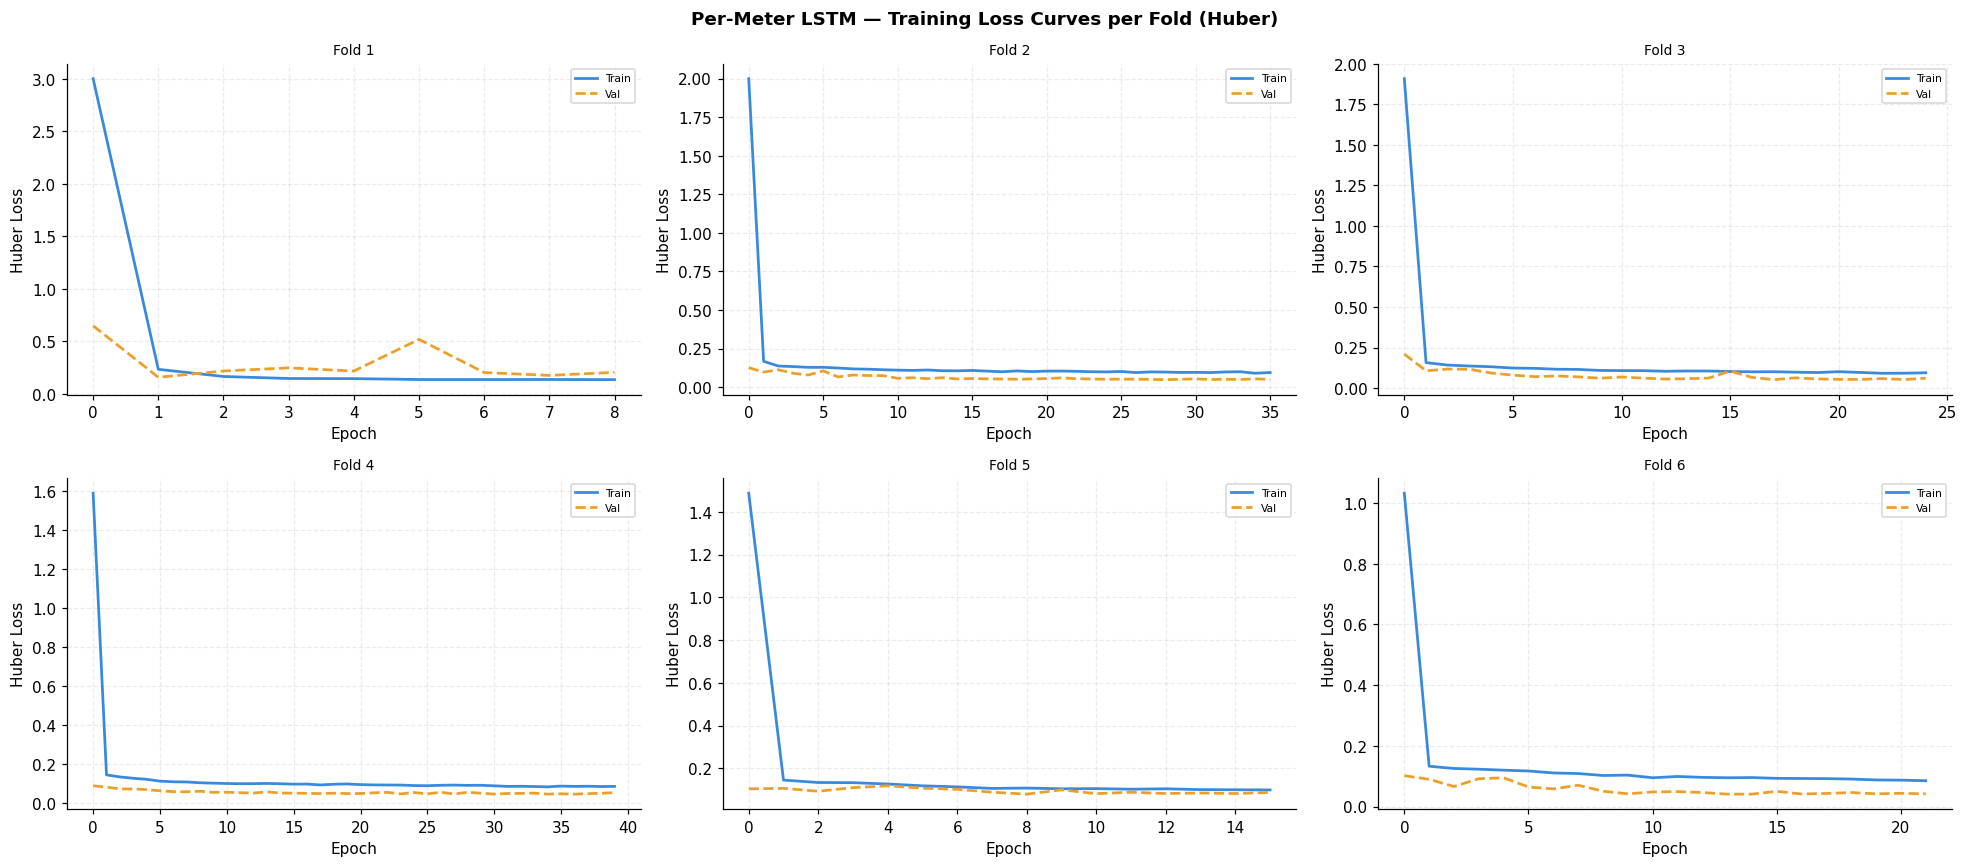

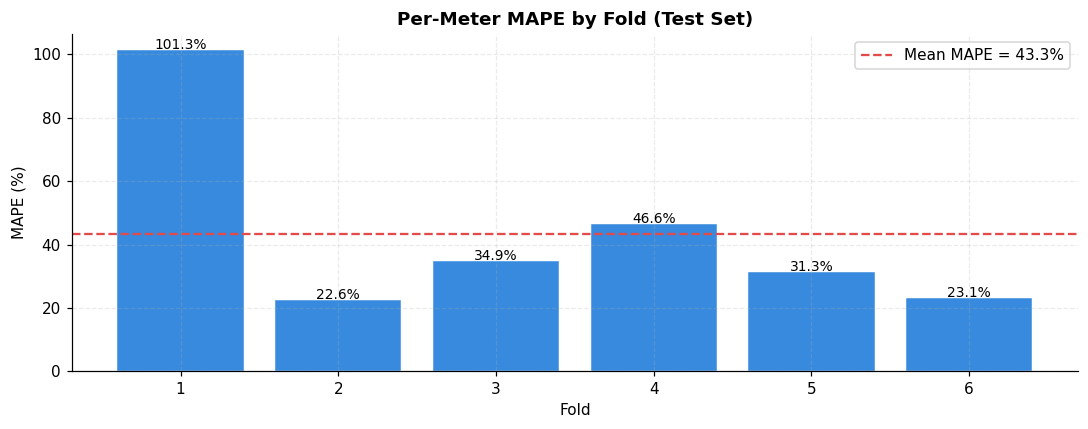

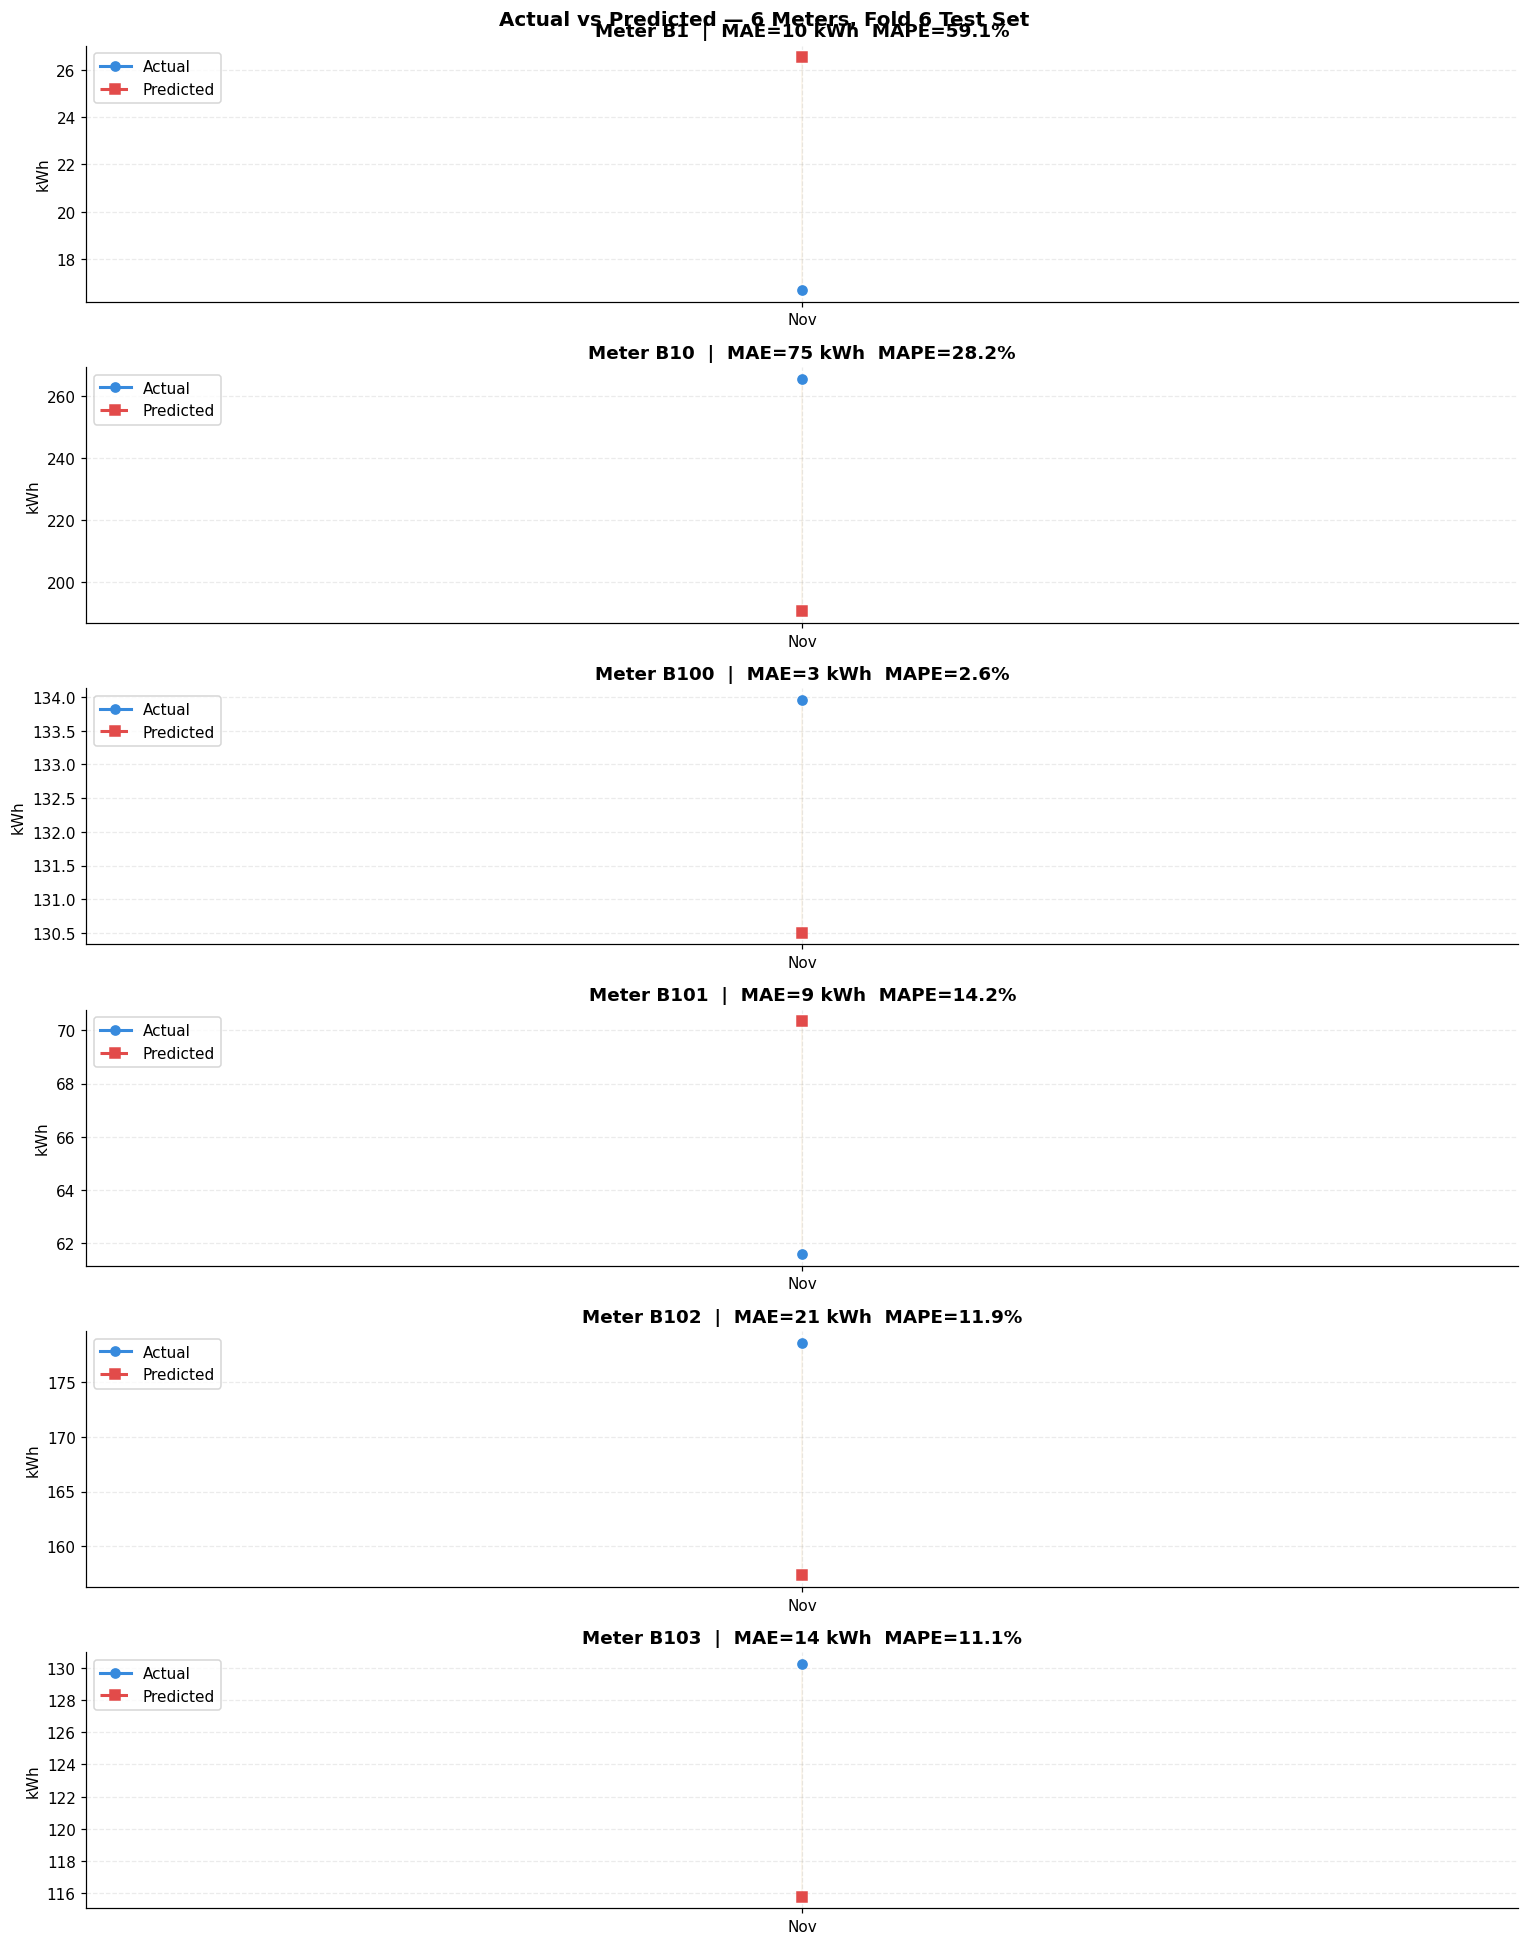

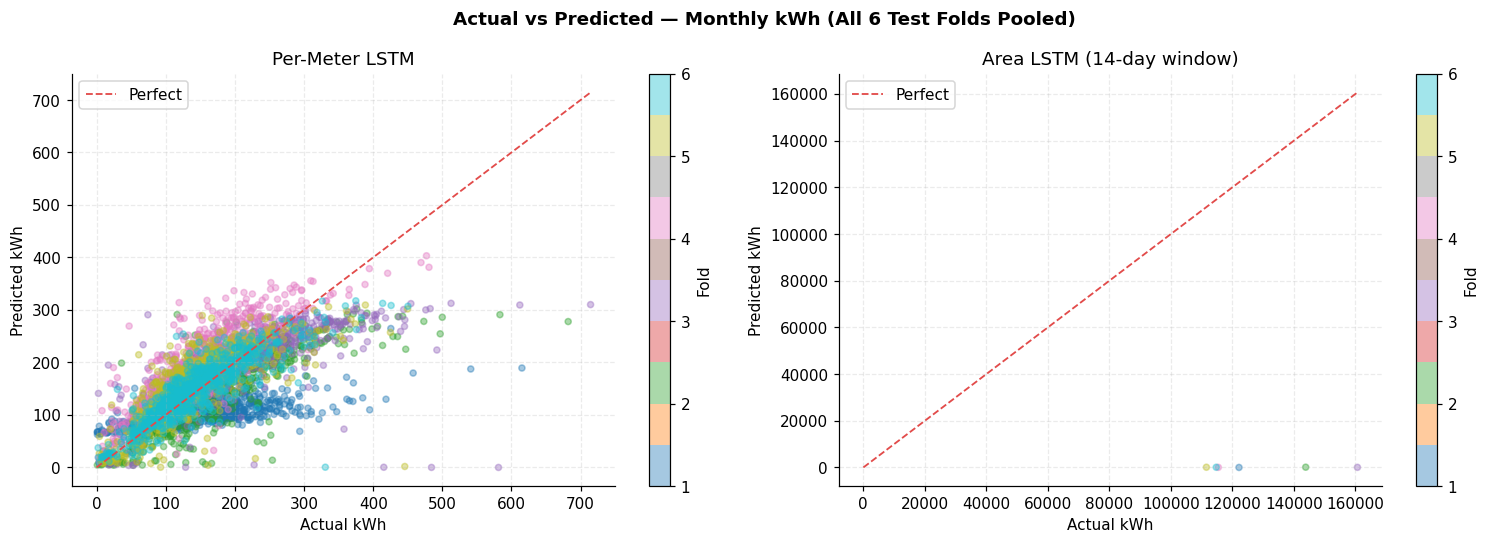

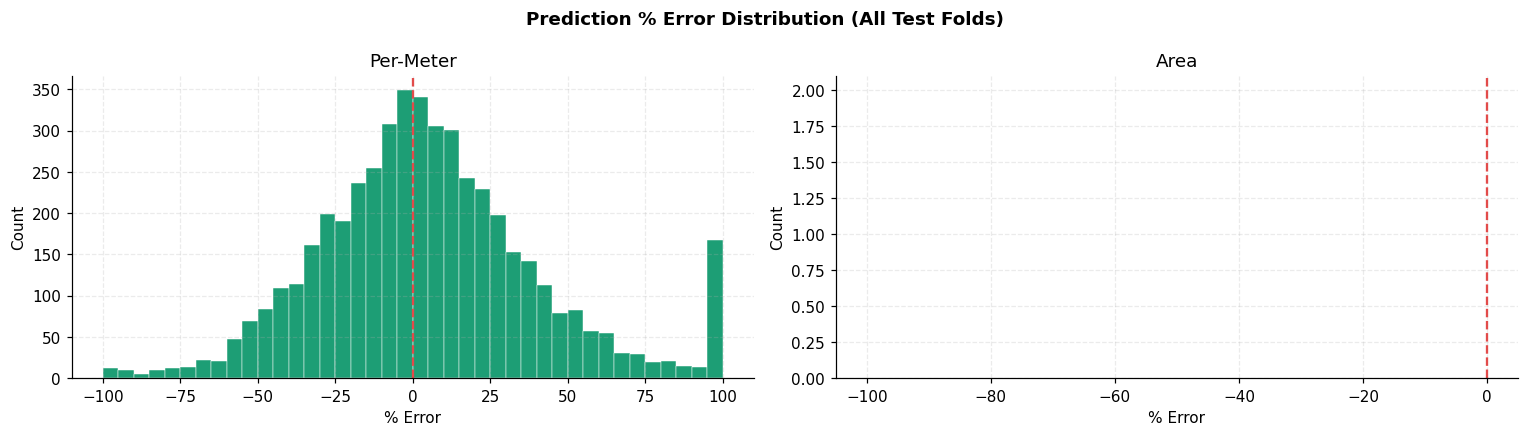

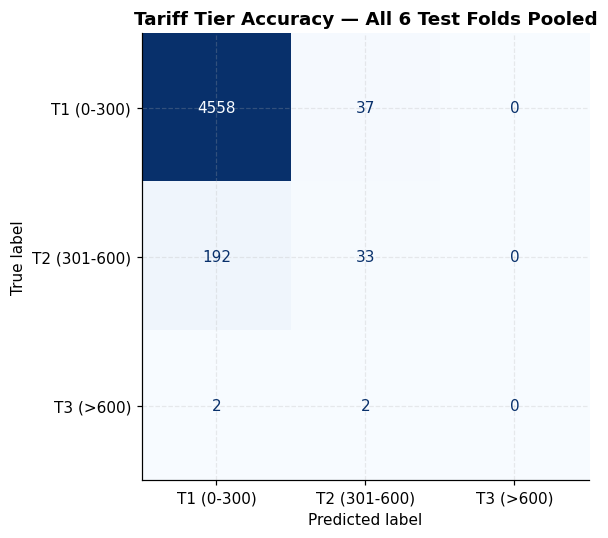

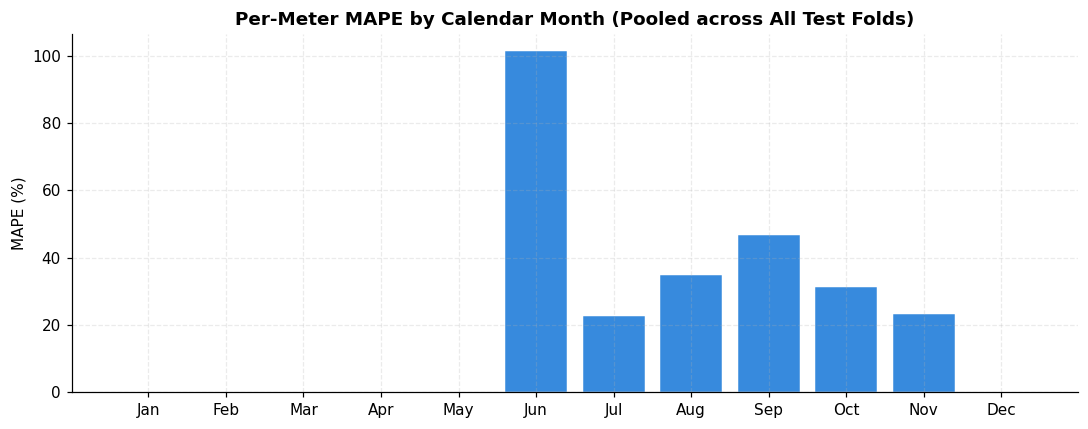

In [12]:
# =============================================================================
# SECTION 10 — Visualisations
# =============================================================================

C_BLUE  = '#378ADD'
C_RED   = '#E24B4A'
C_AMBER = '#EF9F27'
C_TEAL  = '#1D9E75'
C_GRAY  = '#888780'

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
})

# ── 10A Loss curves for all 6 folds (meter model) ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Per-Meter LSTM — Training Loss Curves per Fold (Huber)', fontweight='bold')
for ax, fd in zip(axes.flatten(), folds_data):
    hist = fd['m_history']
    ax.plot(hist['train'], lw=1.8, color=C_BLUE,  label='Train')
    ax.plot(hist['val'],   lw=1.8, color=C_AMBER, label='Val', ls='--')
    ax.set_title(f"Fold {fd['fold']}", fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# ── 10B MAPE per fold (bar chart) ─────────────────────────────────────────────
fold_mapes = m_res_all.groupby('fold').apply(
    lambda g: mape(g['actual'].values, g['predicted'].values))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(fold_mapes.index, fold_mapes.values, color=C_BLUE, edgecolor='white', lw=0.3)
for b, v in zip(bars, fold_mapes.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.axhline(fold_mapes.mean(), color=C_RED, ls='--', lw=1.5,
           label=f'Mean MAPE = {fold_mapes.mean():.1f}%')
ax.set_xlabel('Fold'); ax.set_ylabel('MAPE (%)')
ax.set_title('Per-Meter MAPE by Fold (Test Set)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# ── 10C Actual vs Predicted — 6 sample meters from last fold ─────────────────
last_fold_te = folds_data[-1]['m_res_te']
sample_meters = list(last_fold_te['id'].unique())[:6]
fig, axes = plt.subplots(6, 1, figsize=(14, 18))
fig.suptitle(f'Actual vs Predicted — 6 Meters, Fold {CFG["N_FOLDS"]} Test Set',
             fontweight='bold', fontsize=13)
for ax, mid in zip(axes, sample_meters):
    sub = last_fold_te[last_fold_te['id'] == mid].sort_values('month')
    ax.plot(sub['month'], sub['actual'],    'o-', color=C_BLUE, lw=2, label='Actual')
    ax.plot(sub['month'], sub['predicted'], 's--', color=C_RED,  lw=2, label='Predicted')
    ax.fill_between(sub['month'], sub['actual'], sub['predicted'],
                    alpha=0.1, color=C_AMBER)
    ax.set_title(f'Meter {mid}  |  MAE={sub["abs_err"].mean():.0f} kWh  '
                 f'MAPE={sub["pct_err"].abs().mean():.1f}%', fontweight='bold')
    ax.set_xticks(sub['month'].tolist())
    ax.set_xticklabels([month_names[m] for m in sub['month']])
    ax.set_ylabel('kWh'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# ── 10D Scatter: actual vs predicted (all folds pooled) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actual vs Predicted — Monthly kWh (All 6 Test Folds Pooled)', fontweight='bold')
for ax, res, lbl in [(axes[0], m_res_all, 'Per-Meter LSTM'),
                     (axes[1], a_res_all, 'Area LSTM (14-day window)')]:
    mn = min(res['actual'].min(), res['predicted'].min())
    mx = max(res['actual'].max(), res['predicted'].max())
    sc = ax.scatter(res['actual'], res['predicted'],
                    c=res['fold'], cmap='tab10', alpha=0.4, s=16)
    ax.plot([mn, mx], [mn, mx], '--', color=C_RED, lw=1.2, label='Perfect')
    plt.colorbar(sc, ax=ax, label='Fold')
    ax.set_title(lbl); ax.set_xlabel('Actual kWh'); ax.set_ylabel('Predicted kWh')
    ax.legend()
plt.tight_layout(); plt.show()

# ── 10E % Error distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Prediction % Error Distribution (All Test Folds)', fontweight='bold')
for ax, res, lbl in [(axes[0], m_res_all, 'Per-Meter'),
                     (axes[1], a_res_all, 'Area')]:
    ax.hist(res['pct_err'].clip(-100, 100), bins=40, color=C_TEAL,
            edgecolor='white', lw=0.3)
    ax.axvline(0, color=C_RED, lw=1.5, ls='--')
    ax.set_title(lbl); ax.set_xlabel('% Error'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

# ── 10F Tariff tier confusion matrix (pooled) ─────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
tier_order = ['T1 (0-300)', 'T2 (301-600)', 'T3 (>600)']
cm = confusion_matrix(
    m_res_all['act_tier'].astype(str),
    m_res_all['pred_tier'].astype(str),
    labels=tier_order
)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=tier_order).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Tariff Tier Accuracy — All 6 Test Folds Pooled', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 10G MAPE by calendar month (pooled across folds) ─────────────────────────
month_mape = m_res_all.groupby('month').apply(
    lambda g: mape(g['actual'].values, g['predicted'].values)
).reindex(range(1, 13))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), month_mape.fillna(0).values, color=C_BLUE, edgecolor='white', lw=0.3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])
ax.set_title('Per-Meter MAPE by Calendar Month (Pooled across All Test Folds)', fontweight='bold')
ax.set_ylabel('MAPE (%)')
plt.tight_layout(); plt.show()

In [ ]:
# =============================================================================
# SECTION 11 — Save results
# =============================================================================

m_res_all.to_csv('JEPCO_meter_forecast_walkforward.csv', index=False)
a_res_all.to_csv('JEPCO_area_forecast_walkforward.csv',  index=False)

print('Saved results:')
print('  JEPCO_meter_forecast_walkforward.csv')
print('  JEPCO_area_forecast_walkforward.csv')
print('Saved models:')
for f in range(1, CFG['N_FOLDS'] + 1):
    print(f'  jepco_meter_fold{f}.pt  |  jepco_area_fold{f}.pt')

In [13]:
# =============================================================================
# SECTION 12 — Inference functions
# =============================================================================
# For production inference, use the model trained on the LAST fold
# (it has seen the most data — Dec 8 through Sep 30).
# =============================================================================

def forecast_meter(meter_id, df_full, model, scaler, feats,
                   input_steps=None):
    """
    Predict next-month total kWh + tariff tier + estimated bill for one meter.
    Uses the most recent input_steps rows available for that meter.
    """
    if input_steps is None:
        input_steps = CFG['INPUT_STEPS']

    sub = df_full[df_full['meter_B'] == meter_id].sort_values('freeze_date')
    if len(sub) < input_steps:
        raise ValueError(f'Need {input_steps} rows, got {len(sub)} for meter {meter_id}')

    window   = sub.iloc[-input_steps:][feats].values.astype('float32')
    window   = np.nan_to_num(window, nan=0.0)
    window_s = scaler.transform(window)

    model.eval()
    with torch.no_grad():
        xb = torch.tensor(window_s, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred_kwh = float(unlog_ys([model(xb).item()])[0])

    tier = ('T1 (0-300)'   if pred_kwh <= 300
            else 'T2 (301-600)' if pred_kwh <= 600
            else 'T3 (>600)')

    return {
        'meter_id'           : meter_id,
        'predicted_kwh'      : round(pred_kwh, 2),
        'tariff_tier'        : tier,
        'estimated_bill_jod' : calc_bill_jod(pred_kwh),
    }


def forecast_area(df_full, model, scaler, feats, input_steps=None):
    """
    Predict next-month total area kWh.
    """
    if input_steps is None:
        input_steps = CFG['AREA_INPUT_STEPS']

    area = make_area(df_full, feats, TARGET_COL).sort_values('freeze_date')
    if len(area) < input_steps:
        raise ValueError(f'Need {input_steps} area rows, got {len(area)}')

    window   = area.iloc[-input_steps:][feats].values.astype('float32')
    window   = np.nan_to_num(window, nan=0.0)
    window_s = scaler.transform(window)

    model.eval()
    with torch.no_grad():
        xb = torch.tensor(window_s, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred_kwh = float(unlog_ys([model(xb).item()])[0])

    n_meters = df_full['meter_B'].nunique()
    return {
        'predicted_area_kwh' : round(pred_kwh, 1),
        'avg_per_meter_kwh'  : round(pred_kwh / n_meters, 2) if n_meters else None,
    }


# ── Example: run inference using last fold's model on full dataset ────────────
last_fd = folds_data[-1]

# Reconstruct df_full from all fold splits (full scaled dataset)
df_full = pd.read_csv(
    os.path.join(CFG['splits_dir'], 'df_scaled_full.csv'),
    parse_dates=['freeze_date']
).sort_values(['meter_B', 'freeze_date']).reset_index(drop=True)
df_full = df_full.drop(columns=[c for c in _DROP_COLS if c in df_full.columns])

example_meter = df_full['meter_B'].unique()[0]

result = forecast_meter(
    example_meter, df_full,
    last_fd['meter_model'], last_fd['m_scaler'], FEATS
)
print('Per-meter forecast (last fold model):')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

print()
area_result = forecast_area(
    df_full,
    last_fd['area_model'], last_fd['a_scaler'], FEATS
)
print('Area-level forecast (last fold model):')
for k, v in area_result.items():
    print(f'  {k:25s}: {v:,.1f} kWh')

Per-meter forecast (last fold model):
  meter_id                 : B1
  predicted_kwh            : 15.6
  tariff_tier              : T1 (0-300)
  estimated_bill_jod       : 1.75

Area-level forecast (last fold model):
  predicted_area_kwh       : 78.2 kWh
  avg_per_meter_kwh        : 0.1 kWh


In [14]:
# Save all 6 fold models
for fd in folds_data:
    f = fd['fold']
    torch.save(fd['meter_model'].state_dict(), f'jepco_meter_fold{f}.pt')
    torch.save(fd['area_model'].state_dict(), f'jepco_area_fold{f}.pt')

print('All models saved successfully!')

All models saved successfully!


Plotting VIZ 1: Walk-Forward Forecast Timeline...


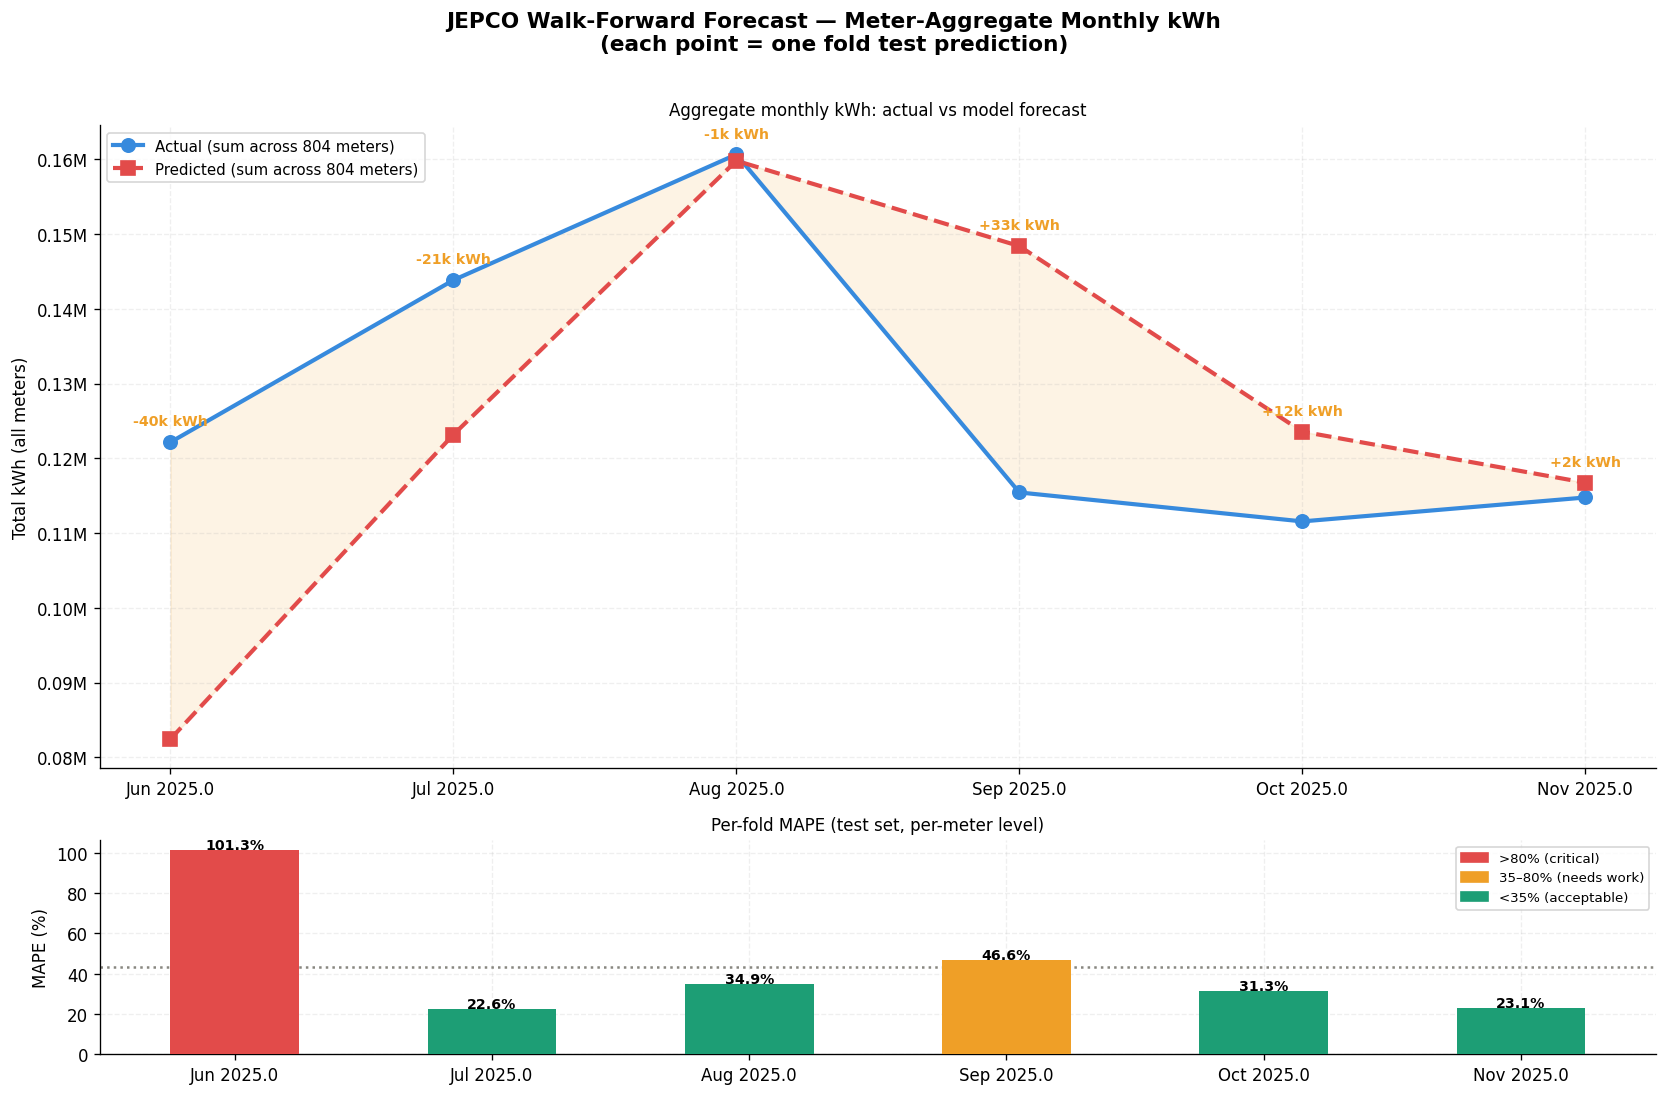

  Saved → viz1_walkforward_timeline.png

Plotting VIZ 2: Actual vs Predicted scatter...


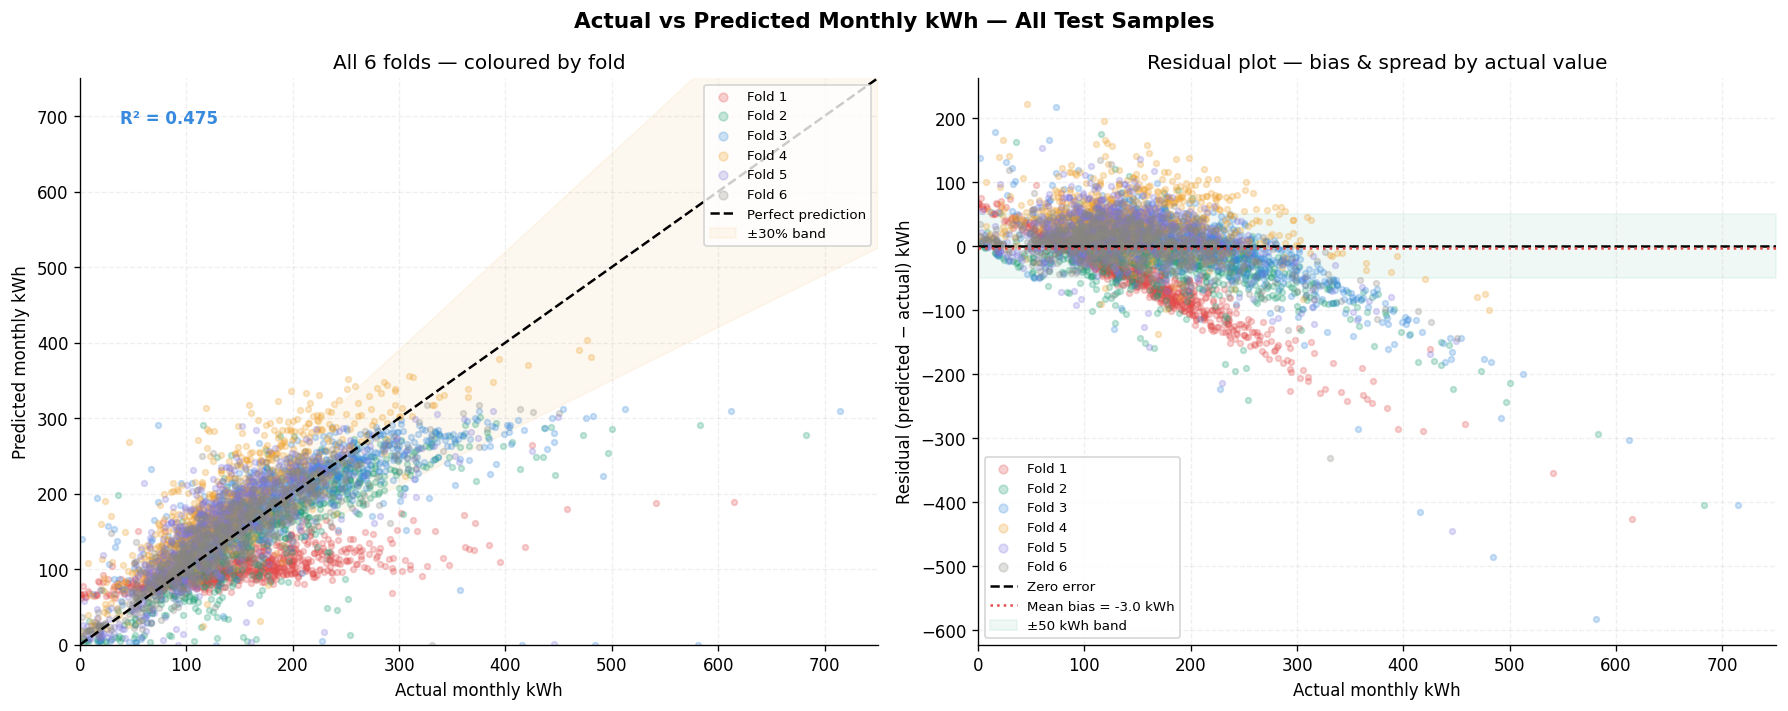

  Saved → viz2_scatter_residuals.png

Plotting VIZ 3: Per-meter forecast gallery (last fold)...


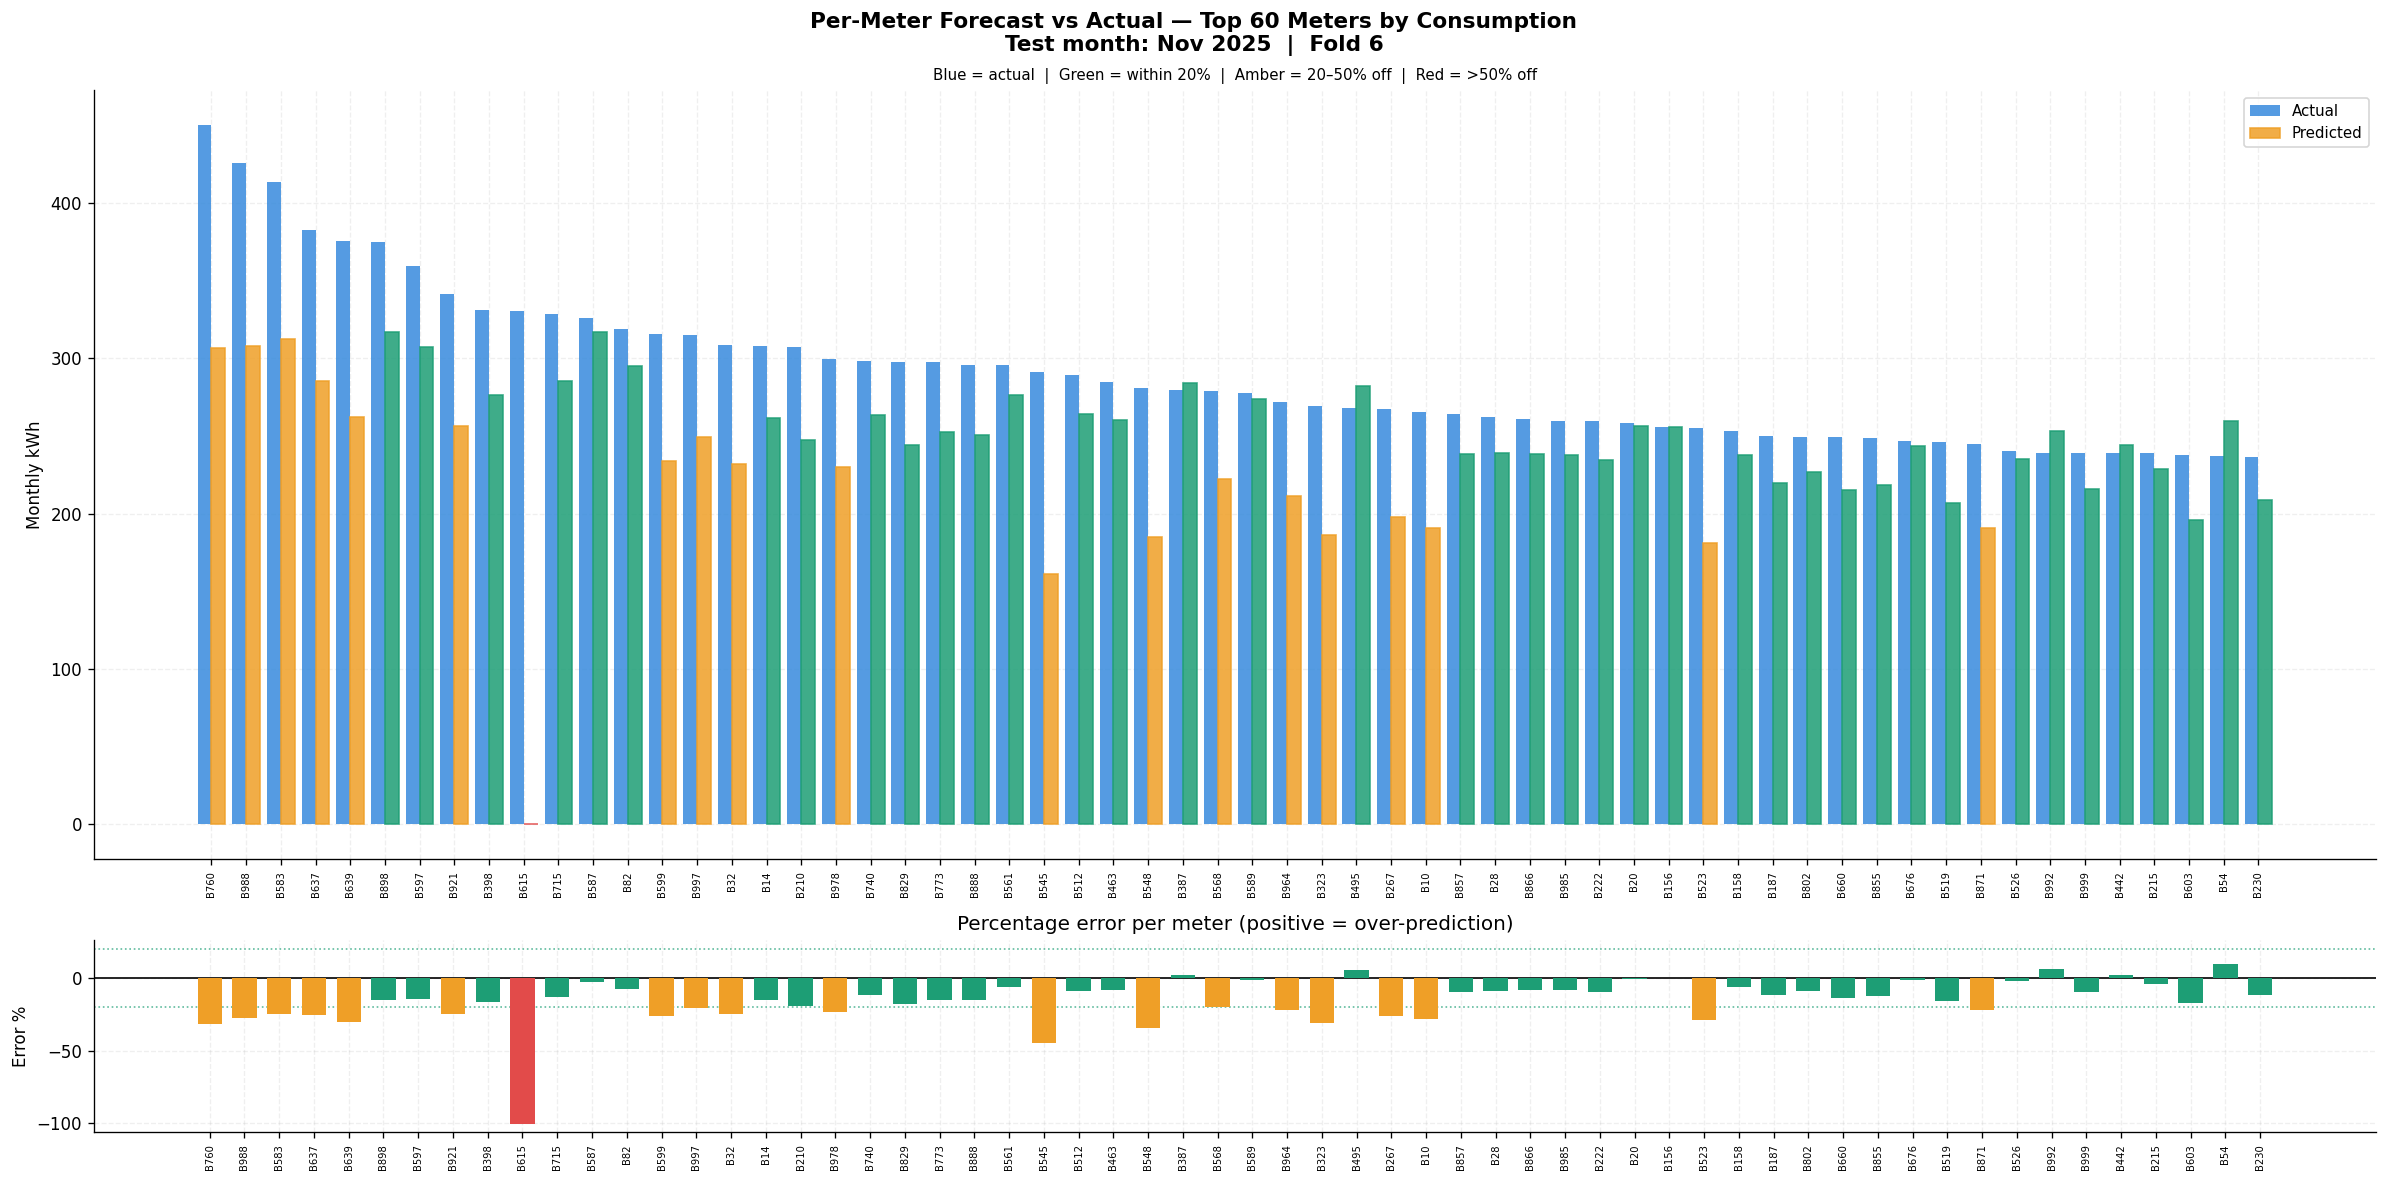

  Saved → viz3_per_meter_forecast_gallery.png

Plotting VIZ 4: Individual meter deep-dives across all folds...


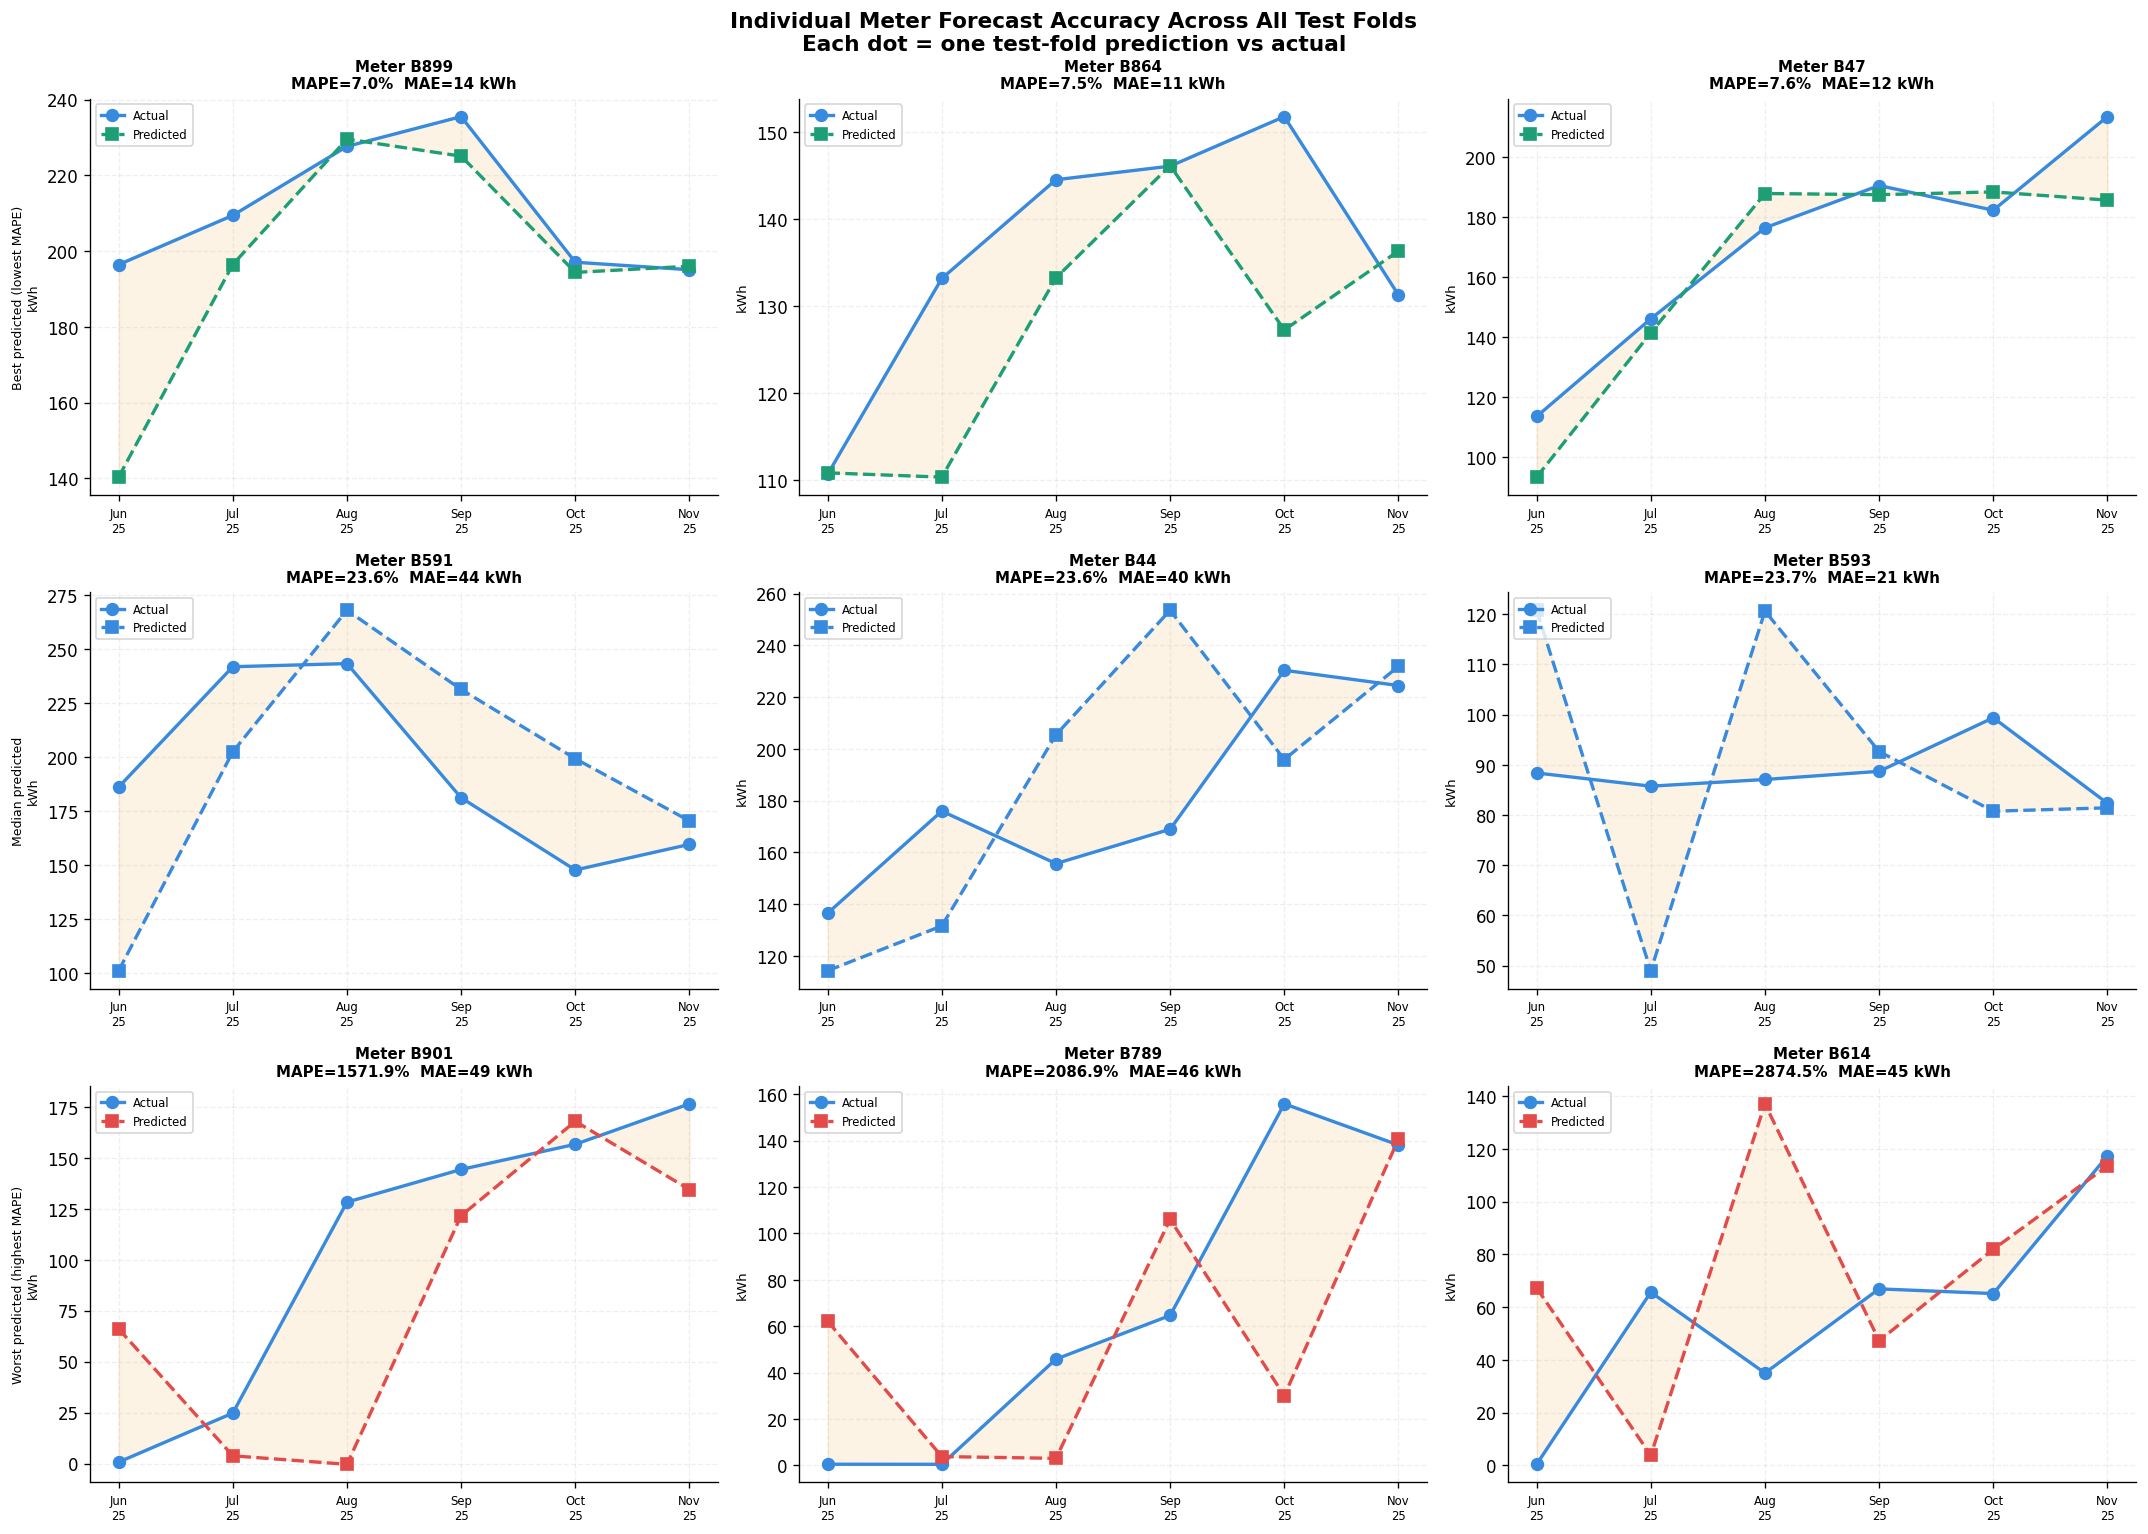

  Saved → viz4_meter_deepdive.png

Plotting VIZ 5: Error distribution & tier accuracy...


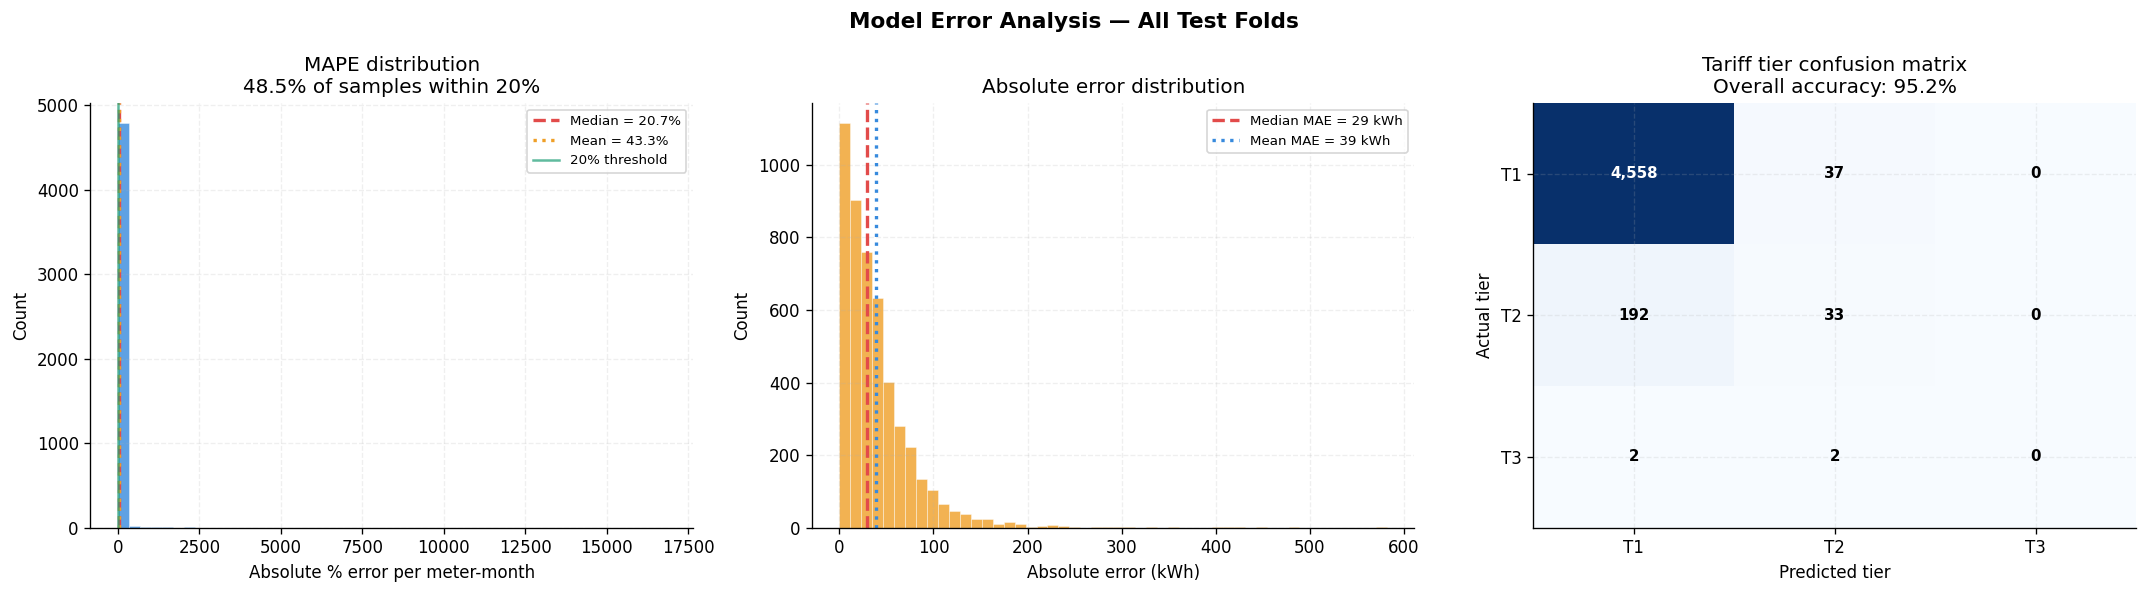

  Saved → viz5_error_distribution_tier.png

Plotting VIZ 6: Training loss curves (all folds overlay)...


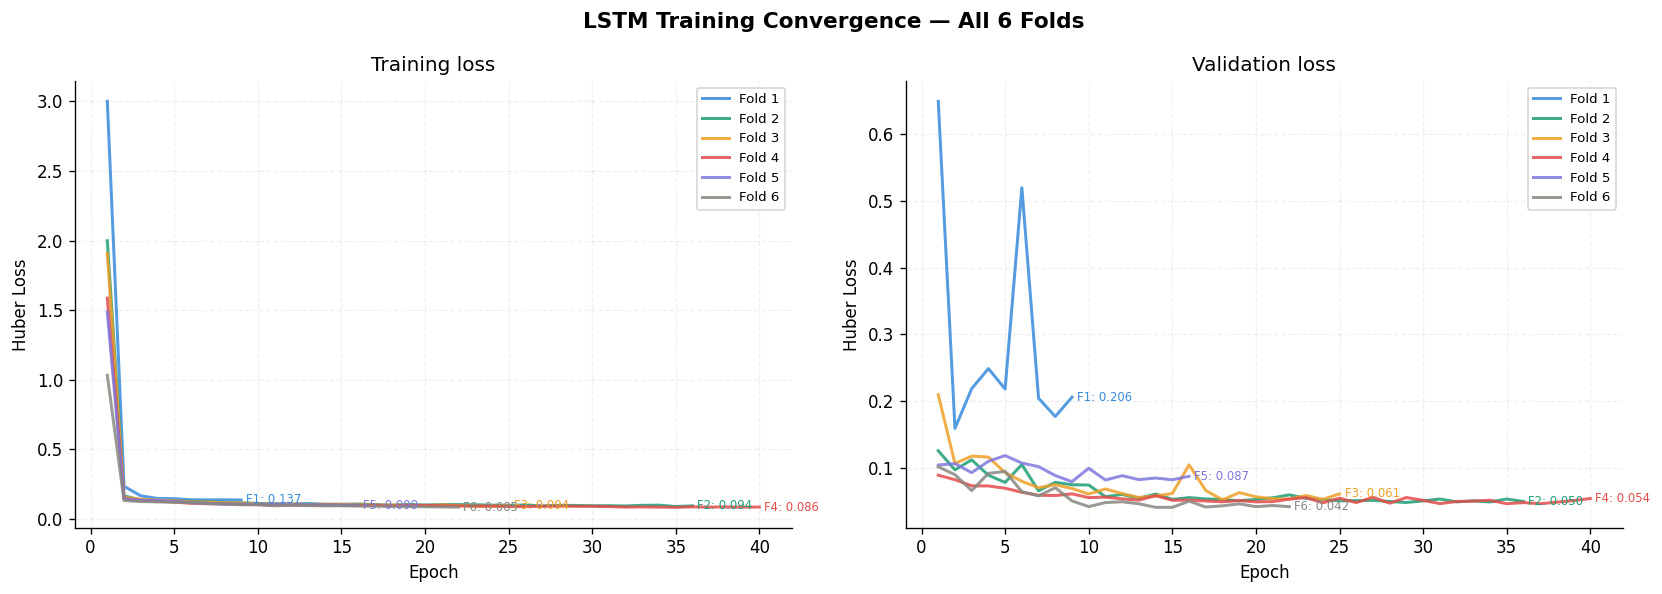

  Saved → viz6_loss_curves_overlay.png

VISUALIZATION SUMMARY
  viz1_walkforward_timeline.png      — aggregate forecast timeline
  viz2_scatter_residuals.png         — actual vs predicted scatter
  viz3_per_meter_forecast_gallery.png — top-60 meter bar chart
  viz4_meter_deepdive.png            — best/median/worst meters
  viz5_error_distribution_tier.png   — error histogram + tier matrix
  viz6_loss_curves_overlay.png       — training convergence

KEY METRICS ACROSS ALL 6 TEST FOLDS:
  Samples evaluated : 4,824
  Mean MAPE         : 43.3%
  Median abs error  : 29.0 kWh
  Tier accuracy     : 95.2%
  % within 20% MAPE : 48.5%
  Systematic bias   : -3.0 kWh (neg = under-prediction)


In [15]:
# =============================================================================
# SECTION 13 — Enhanced Visualizations
# Paste this entire cell into your notebook and run it after Section 10.
# Requires: m_res_all, a_res_all, folds_data (all produced by Section 8)
# =============================================================================

# ── Shared style ──────────────────────────────────────────────────────────────
C_BLUE   = '#378ADD'
C_RED    = '#E24B4A'
C_AMBER  = '#EF9F27'
C_TEAL   = '#1D9E75'
C_GRAY   = '#888780'
C_PURPLE = '#7F77DD'

MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
    'font.size': 10,
})

def mape(y_true, y_pred, eps=1e-6):
    return float(np.mean(np.abs((np.array(y_true) - np.array(y_pred)) /
                                (np.array(y_true) + eps))) * 100)

# =============================================================================
# VIZ 1 — Walk-Forward Forecast Timeline (area-level, all 6 test months)
# Shows the single test prediction per fold as a timeline against actuals.
# =============================================================================

print("Plotting VIZ 1: Walk-Forward Forecast Timeline...")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('JEPCO Walk-Forward Forecast — Meter-Aggregate Monthly kWh\n(each point = one fold test prediction)',
             fontweight='bold', fontsize=13, y=1.01)

ax = axes[0]

# Build a per-fold summary: sum predicted/actual across all meters in that test month
fold_summary = (m_res_all.groupby('fold')
                .agg(actual_sum=('actual', 'sum'),
                     predicted_sum=('predicted', 'sum'),
                     test_month=('month', 'first'),
                     test_year=('year', 'first'))
                .reset_index())
fold_summary['label'] = fold_summary.apply(
    lambda r: f"{MONTH_NAMES[r['test_month']]} {r['test_year']}", axis=1)
fold_summary['fold_mape'] = [
    mape(m_res_all[m_res_all['fold']==f]['actual'].values,
         m_res_all[m_res_all['fold']==f]['predicted'].values)
    for f in fold_summary['fold']
]

x = np.arange(len(fold_summary))

ax.fill_between(x, fold_summary['actual_sum'], fold_summary['predicted_sum'],
                alpha=0.12, color=C_AMBER, label='_nolegend_')
ax.plot(x, fold_summary['actual_sum'],
        'o-', color=C_BLUE, lw=2.5, ms=8, label='Actual (sum across 804 meters)', zorder=3)
ax.plot(x, fold_summary['predicted_sum'],
        's--', color=C_RED, lw=2.5, ms=8, label='Predicted (sum across 804 meters)', zorder=3)

# Annotate each point with the gap
for i, row in fold_summary.iterrows():
    diff = row['predicted_sum'] - row['actual_sum']
    sign = '+' if diff >= 0 else ''
    ax.annotate(f"{sign}{diff/1000:.0f}k kWh",
                xy=(i, max(row['actual_sum'], row['predicted_sum'])),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color=C_AMBER, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(fold_summary['label'], rotation=0)
ax.set_ylabel('Total kWh (all meters)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.2f}M'))
ax.legend(loc='upper left', fontsize=9)
ax.set_title('Aggregate monthly kWh: actual vs model forecast', fontsize=10)

# Bottom panel: MAPE per fold
ax2 = axes[1]
colors = [C_RED if v > 80 else C_AMBER if v > 35 else C_TEAL for v in fold_summary['fold_mape']]
bars = ax2.bar(x, fold_summary['fold_mape'], color=colors, width=0.5, zorder=3)
for b, v in zip(bars, fold_summary['fold_mape']):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%',
             ha='center', fontsize=8.5, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(fold_summary['label'], rotation=0)
ax2.set_ylabel('MAPE (%)')
ax2.set_title('Per-fold MAPE (test set, per-meter level)', fontsize=10)
ax2.axhline(fold_summary['fold_mape'].mean(), color=C_GRAY, ls=':', lw=1.5,
            label=f"Mean = {fold_summary['fold_mape'].mean():.1f}%")
ax2.legend(fontsize=8)

# Legend for bar colors
patches = [mpatches.Patch(color=C_RED, label='>80% (critical)'),
           mpatches.Patch(color=C_AMBER, label='35–80% (needs work)'),
           mpatches.Patch(color=C_TEAL, label='<35% (acceptable)')]
ax2.legend(handles=patches, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('viz1_walkforward_timeline.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz1_walkforward_timeline.png")


# =============================================================================
# VIZ 2 — Actual vs Predicted scatter with identity line + error bands
# One dot per meter-month test sample, coloured by fold
# =============================================================================

print("\nPlotting VIZ 2: Actual vs Predicted scatter...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Actual vs Predicted Monthly kWh — All Test Samples',
             fontweight='bold', fontsize=13)

fold_colors = [C_RED, C_TEAL, C_BLUE, C_AMBER, C_PURPLE, C_GRAY]

# Left: all folds together
ax = axes[0]
for fd_color, fold_num in zip(fold_colors, range(1, 7)):
    sub = m_res_all[m_res_all['fold'] == fold_num]
    ax.scatter(sub['actual'], sub['predicted'],
               alpha=0.25, s=12, color=fd_color,
               label=f"Fold {fold_num}", zorder=2)

# Perfect prediction line
lim_max = m_res_all[['actual','predicted']].max().max() * 1.05
lim_min = 0
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='black', lw=1.5, ls='--', label='Perfect prediction', zorder=3)

# ±30% error bands
ax.fill_between([lim_min, lim_max],
                [lim_min * 0.7, lim_max * 0.7],
                [lim_min * 1.3, lim_max * 1.3],
                alpha=0.07, color=C_AMBER, label='±30% band')

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('Actual monthly kWh')
ax.set_ylabel('Predicted monthly kWh')
ax.set_title('All 6 folds — coloured by fold')
ax.legend(fontsize=8, markerscale=1.5)

# Add R² annotation
from numpy.polynomial import polynomial as P
actual_vals = m_res_all['actual'].values
pred_vals   = m_res_all['predicted'].values
ss_res = np.sum((actual_vals - pred_vals)**2)
ss_tot = np.sum((actual_vals - actual_vals.mean())**2)
r2 = 1 - ss_res / ss_tot
ax.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color=C_BLUE)

# Right: residuals (predicted - actual) vs actual
ax2 = axes[1]
residuals = m_res_all['predicted'] - m_res_all['actual']
for fd_color, fold_num in zip(fold_colors, range(1, 7)):
    sub = m_res_all[m_res_all['fold'] == fold_num]
    res_sub = sub['predicted'] - sub['actual']
    ax2.scatter(sub['actual'], res_sub,
                alpha=0.25, s=12, color=fd_color,
                label=f"Fold {fold_num}", zorder=2)

ax2.axhline(0, color='black', lw=1.5, ls='--', label='Zero error', zorder=3)
ax2.axhline(residuals.mean(), color=C_RED, lw=1.5, ls=':',
            label=f'Mean bias = {residuals.mean():.1f} kWh', zorder=3)
ax2.fill_between([lim_min, lim_max], [-50, -50], [50, 50],
                 alpha=0.07, color=C_TEAL, label='±50 kWh band')

ax2.set_xlim(lim_min, lim_max)
ax2.set_xlabel('Actual monthly kWh')
ax2.set_ylabel('Residual (predicted − actual) kWh')
ax2.set_title('Residual plot — bias & spread by actual value')
ax2.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig('viz2_scatter_residuals.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz2_scatter_residuals.png")


# =============================================================================
# VIZ 3 — Per-meter forecast gallery (last fold)
# Shows the model's prediction for each meter's test month as a bar chart
# with actual side by side, sorted by actual consumption
# =============================================================================

print("\nPlotting VIZ 3: Per-meter forecast gallery (last fold)...")

last_te = folds_data[-1]['m_res_te'].copy()
last_te = last_te.sort_values('actual', ascending=False).reset_index(drop=True)
fold_n = last_te['fold'].iloc[0] if 'fold' in last_te.columns else CFG['N_FOLDS']
test_month_label = (f"{MONTH_NAMES.get(last_te['month'].iloc[0], '?')} "
                    f"{last_te['year'].iloc[0]}")

# Show top 60 meters by actual consumption (one page)
TOP_N = 60
sub = last_te.head(TOP_N)
n_meters = len(sub)
x = np.arange(n_meters)
width = 0.4

fig, axes = plt.subplots(2, 1, figsize=(20, 10),
                          gridspec_kw={'height_ratios': [4, 1]})
fig.suptitle(f'Per-Meter Forecast vs Actual — Top {TOP_N} Meters by Consumption\n'
             f'Test month: {test_month_label}  |  Fold {fold_n}',
             fontweight='bold', fontsize=13)

ax = axes[0]
bars_a = ax.bar(x - width/2, sub['actual'],    width, color=C_BLUE,
                label='Actual', alpha=0.85, zorder=3)
bars_p = ax.bar(x + width/2, sub['predicted'], width, color=C_RED,
                label='Predicted', alpha=0.85, zorder=3)

# Colour the predicted bar green if within 20%, red if >50% off
for bar, (_, row) in zip(bars_p, sub.iterrows()):
    pct = abs(row['predicted'] - row['actual']) / (row['actual'] + 1e-6)
    if pct < 0.20:
        bar.set_color(C_TEAL)
    elif pct > 0.50:
        bar.set_color(C_RED)
    else:
        bar.set_color(C_AMBER)

ax.set_xticks(x)
ax.set_xticklabels(sub['id'].tolist(), rotation=90, fontsize=6)
ax.set_ylabel('Monthly kWh')
ax.set_title(f'Blue = actual  |  Green = within 20%  |  Amber = 20–50% off  |  Red = >50% off',
             fontsize=9)
ax.legend(fontsize=9)

# Bottom panel: % error per meter
ax2 = axes[1]
pct_errors = ((sub['predicted'] - sub['actual']) / (sub['actual'] + 1e-6) * 100).values
bar_colors = [C_TEAL if abs(e) < 20 else C_AMBER if abs(e) < 50 else C_RED
              for e in pct_errors]
ax2.bar(x, pct_errors, color=bar_colors, width=0.7, zorder=3)
ax2.axhline(0, color='black', lw=1, ls='-')
ax2.axhline(20,  color=C_TEAL,  lw=1, ls=':', alpha=0.7)
ax2.axhline(-20, color=C_TEAL,  lw=1, ls=':', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(sub['id'].tolist(), rotation=90, fontsize=6)
ax2.set_ylabel('Error %')
ax2.set_title('Percentage error per meter (positive = over-prediction)')

plt.tight_layout()
plt.savefig('viz3_per_meter_forecast_gallery.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz3_per_meter_forecast_gallery.png")


# =============================================================================
# VIZ 4 — Individual meter time-series deep-dives (best + worst + median)
# For each selected meter, plot actual vs predicted across ALL test folds
# =============================================================================

print("\nPlotting VIZ 4: Individual meter deep-dives across all folds...")

# Rank meters by their average absolute % error across folds
meter_error = (m_res_all
               .groupby('id')
               .apply(lambda g: mape(g['actual'].values, g['predicted'].values))
               .reset_index(name='mape'))
meter_error = meter_error.sort_values('mape').reset_index(drop=True)

best_meters   = meter_error.head(3)['id'].tolist()
worst_meters  = meter_error.tail(3)['id'].tolist()
median_idx    = len(meter_error) // 2
median_meters = meter_error.iloc[median_idx-1:median_idx+2]['id'].tolist()

selected_groups = [
    ('Best predicted (lowest MAPE)',  best_meters,   C_TEAL),
    ('Median predicted',              median_meters, C_BLUE),
    ('Worst predicted (highest MAPE)',worst_meters,  C_RED),
]

fig, all_axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('Individual Meter Forecast Accuracy Across All Test Folds\n'
             'Each dot = one test-fold prediction vs actual',
             fontweight='bold', fontsize=13)

for row_idx, (group_title, meter_ids, color) in enumerate(selected_groups):
    for col_idx, mid in enumerate(meter_ids):
        ax = all_axes[row_idx][col_idx]
        sub = m_res_all[m_res_all['id'] == mid].sort_values(['year','month'])
        
        if sub.empty:
            ax.set_visible(False)
            continue
        
        x_labels = [f"{MONTH_NAMES.get(r['month'],'?')}\n{str(r['year'])[2:]}"
                    for _, r in sub.iterrows()]
        x_pos = np.arange(len(sub))
        
        ax.plot(x_pos, sub['actual'],    'o-', color=C_BLUE, lw=2, ms=7,
                label='Actual', zorder=3)
        ax.plot(x_pos, sub['predicted'], 's--', color=color, lw=2, ms=7,
                label='Predicted', zorder=3)
        ax.fill_between(x_pos, sub['actual'], sub['predicted'],
                        alpha=0.12, color=C_AMBER)
        
        meter_m = mape(sub['actual'].values, sub['predicted'].values)
        mae_v   = mean_absolute_error(sub['actual'], sub['predicted'])
        ax.set_title(f'Meter {mid}\nMAPE={meter_m:.1f}%  MAE={mae_v:.0f} kWh',
                     fontsize=9, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=7)
        ax.set_ylabel('kWh', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(group_title + '\nkWh', fontsize=7.5)
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('viz4_meter_deepdive.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz4_meter_deepdive.png")


# =============================================================================
# VIZ 5 — Error distribution + tariff tier confusion matrix
# =============================================================================

print("\nPlotting VIZ 5: Error distribution & tier accuracy...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Error Analysis — All Test Folds', fontweight='bold', fontsize=13)

# 5A: MAPE distribution histogram
ax = axes[0]
mape_per_sample = np.abs(m_res_all['pct_err'].values)
ax.hist(mape_per_sample, bins=50, color=C_BLUE, alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(np.median(mape_per_sample), color=C_RED, lw=2, ls='--',
           label=f'Median = {np.median(mape_per_sample):.1f}%')
ax.axvline(np.mean(mape_per_sample), color=C_AMBER, lw=2, ls=':',
           label=f'Mean = {np.mean(mape_per_sample):.1f}%')
ax.axvline(20, color=C_TEAL, lw=1.5, ls='-', alpha=0.7, label='20% threshold')
pct_under20 = (mape_per_sample < 20).mean() * 100
ax.set_xlabel('Absolute % error per meter-month')
ax.set_ylabel('Count')
ax.set_title(f'MAPE distribution\n{pct_under20:.1f}% of samples within 20%')
ax.legend(fontsize=8)

# 5B: Absolute error distribution
ax = axes[1]
abs_errors = m_res_all['abs_err'].values
ax.hist(abs_errors, bins=50, color=C_AMBER, alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(np.median(abs_errors), color=C_RED, lw=2, ls='--',
           label=f'Median MAE = {np.median(abs_errors):.0f} kWh')
ax.axvline(np.mean(abs_errors), color=C_BLUE, lw=2, ls=':',
           label=f'Mean MAE = {np.mean(abs_errors):.0f} kWh')
ax.set_xlabel('Absolute error (kWh)')
ax.set_ylabel('Count')
ax.set_title('Absolute error distribution')
ax.legend(fontsize=8)

# 5C: Tariff tier confusion matrix
ax = axes[2]
tiers = ['T1 (0-300)', 'T2 (301-600)', 'T3 (>600)']
conf = np.zeros((3, 3), dtype=int)
tier_map = {t: i for i, t in enumerate(tiers)}
for _, row in m_res_all.iterrows():
    act_i = tier_map.get(str(row['act_tier']), 0)
    pred_i = tier_map.get(str(row['pred_tier']), 0)
    conf[act_i][pred_i] += 1

im = ax.imshow(conf, cmap='Blues', aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(['T1','T2','T3'])
ax.set_yticks(range(3)); ax.set_yticklabels(['T1','T2','T3'])
ax.set_xlabel('Predicted tier')
ax.set_ylabel('Actual tier')
total_correct = conf.diagonal().sum()
total = conf.sum()
ax.set_title(f'Tariff tier confusion matrix\nOverall accuracy: {total_correct/total*100:.1f}%')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{conf[i,j]:,}',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if conf[i,j] > conf.max() * 0.5 else 'black')

plt.tight_layout()
plt.savefig('viz5_error_distribution_tier.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz5_error_distribution_tier.png")


# =============================================================================
# VIZ 6 — Loss curve comparison: all 6 folds on one plot
# =============================================================================

print("\nPlotting VIZ 6: Training loss curves (all folds overlay)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training Convergence — All 6 Folds', fontweight='bold', fontsize=13)

fold_colors_6 = [C_BLUE, C_TEAL, C_AMBER, C_RED, C_PURPLE, C_GRAY]

for ax_idx, split in enumerate(['train', 'val']):
    ax = axes[ax_idx]
    for fd, color in zip(folds_data, fold_colors_6):
        hist = fd['m_history']
        epochs = range(1, len(hist[split]) + 1)
        ax.plot(epochs, hist[split], color=color, lw=1.8, alpha=0.85,
                label=f"Fold {fd['fold']}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Huber Loss')
    ax.set_title(f'{"Training" if split=="train" else "Validation"} loss')
    ax.legend(fontsize=8)
    # Annotate final loss values
    for fd, color in zip(folds_data, fold_colors_6):
        hist = fd['m_history']
        final_loss = hist[split][-1]
        ax.annotate(f"F{fd['fold']}: {final_loss:.3f}",
                    xy=(len(hist[split]), final_loss),
                    xytext=(3, 0), textcoords='offset points',
                    fontsize=7, color=color, va='center')

plt.tight_layout()
plt.savefig('viz6_loss_curves_overlay.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved → viz6_loss_curves_overlay.png")


# =============================================================================
# Summary printout
# =============================================================================

print("\n" + "="*60)
print("VISUALIZATION SUMMARY")
print("="*60)
print(f"  viz1_walkforward_timeline.png      — aggregate forecast timeline")
print(f"  viz2_scatter_residuals.png         — actual vs predicted scatter")
print(f"  viz3_per_meter_forecast_gallery.png — top-60 meter bar chart")
print(f"  viz4_meter_deepdive.png            — best/median/worst meters")
print(f"  viz5_error_distribution_tier.png   — error histogram + tier matrix")
print(f"  viz6_loss_curves_overlay.png       — training convergence")
print()

# Quick stats summary
print("KEY METRICS ACROSS ALL 6 TEST FOLDS:")
print(f"  Samples evaluated : {len(m_res_all):,}")
print(f"  Mean MAPE         : {mape(m_res_all['actual'], m_res_all['predicted']):.1f}%")
print(f"  Median abs error  : {m_res_all['abs_err'].median():.1f} kWh")
print(f"  Tier accuracy     : {m_res_all['tier_correct'].mean()*100:.1f}%")
print(f"  % within 20% MAPE : {(np.abs(m_res_all['pct_err']) < 20).mean()*100:.1f}%")
print(f"  Systematic bias   : {(m_res_all['predicted'] - m_res_all['actual']).mean():.1f} kWh (neg = under-prediction)")